# EDA — 전처리 후 버전 (eda_test.ipynb)

기존 `eda.ipynb` (161셀) 기반. **Phase 0에서 전처리 먼저 실행** 후 Phase 1~7 진행.

| Phase | 내용 |
|:---:|------|
| **0** | **전처리: cleaning.py + outlier.py (2_preprocessing)** |
| 1 | 데이터 기본 파악 |
| 2 | Feature 품질 검사 |
| 3 | 이상치 및 스케일 |
| 4 | Feature-Target 관계 |
| 5 | Target 심층 분석 + PCA/UMAP 차원축소 |
| 6 | 공간/구조 분석 |
| 7 | 집계 전략 |

## Phase 0-1: 환경 설정 및 데이터 로드

In [ ]:
import os, sys

try:
    import google.colab
    if not os.path.exists("/content/project/setup.py"):
        os.system("pip install -q gdown")
        os.system("gdown --id 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip")
        os.system("unzip -qo /content/code.zip -d /content/project")
        os.makedirs("/content/project/0_data", exist_ok=True)
        os.system("gdown --id 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip")
        os.system("unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data")
        os.remove("/content/project/0_data/dataset.zip")
    # modules 최신버전 다운로드
    os.makedirs("/content/project/1_eda/modules", exist_ok=True)
    os.system("gdown --id 11ZhDlxQOXNb3rN5oul1tO4-VbUfAQD9f -O /content/project/1_eda/modules.zip")
    os.system("unzip -qo /content/project/1_eda/modules.zip -d /content/project/1_eda/modules")
    os.remove("/content/project/1_eda/modules.zip")
    # 전처리 모듈 다운로드 (git sparse-checkout)
    _prep_dir = "/content/project/2_preprocessing"
    os.makedirs(_prep_dir, exist_ok=True)
    os.system("rm -rf /tmp/_sk_prep")
    os.system(
        "git clone --depth=1 --filter=blob:none --sparse "
        "https://github.com/younjunseon/ASAC_SKhynix /tmp/_sk_prep"
    )
    os.system("git -C /tmp/_sk_prep sparse-checkout set 2_preprocessing")
    os.system(f"cp /tmp/_sk_prep/2_preprocessing/*.py {_prep_dir}/")
    os.system("rm -rf /tmp/_sk_prep")
    assert os.path.exists(f"{_prep_dir}/cleaning.py"), "cleaning.py 다운로드 실패"
    sys.path.insert(0, "/content/project")
    sys.path.insert(0, "/content/project/1_eda")
    sys.path.insert(0, _prep_dir)
    os.chdir("/content/project")
except ImportError:
    _here = os.path.abspath(".")
    _prep_local = os.path.normpath(os.path.join(_here, "../../2_preprocessing"))
    sys.path.insert(0, _here)
    sys.path.insert(0, _prep_local)
    pass

# ── 공통: cwd에서 위로 setup.py(+utils/)를 자동탐색 (노트북 깊이·드라이브 위치 무관) ──
_d = os.getcwd()
while not (os.path.exists(os.path.join(_d, 'setup.py')) and os.path.isdir(os.path.join(_d, 'utils'))):
    _p = os.path.dirname(_d)
    if _p == _d:
        raise RuntimeError('프로젝트 루트(setup.py + utils/)를 못 찾음 — cwd 확인')
    _d = _p
if _d not in sys.path:
    sys.path.insert(0, _d)
import runpy
runpy.run_path(os.path.join(_d, 'setup.py'))

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from utils.config import PROJECT_ROOT, META_COLS, KEY_COL
from utils.data import load_all, get_feat_cols, split_xs

xs_raw, ys = load_all()
feat_cols_raw = get_feat_cols(xs_raw)
ys_all = ys["all"]
ys_train = ys["train"]

print(f"원본 데이터: {xs_raw.shape[0]:,}행 × {len(feat_cols_raw)}개 feature")

패키지 설치 중: ['catboost', 'optuna', 'boruta', 'pytorch-tabnet', 'rtdl-revisiting-models']
setup 완료
[load_xs] all-NaN 행 407개 제거 → 174,573행
[load_xs] 4 position 미만 unit 1개 제거 (split별: {'train': 1}) → die 174,573 → 174,572
[load_ys] train: xs에 없는 unit 60개 제거 → 26,187
[load_ys] validation: xs에 없는 unit 22개 제거 → 8,727
[load_ys] test: xs에 없는 unit 20개 제거 → 8,729
Xs: (174572, 1091)  |  Ys: train=26,187, val=8,727, test=8,729
원본 데이터: 174,572행 × 1087개 feature


## Phase 0-2: 전처리 모듈 Import

In [2]:
from cleaning import (
    remove_high_missing_features,
    remove_constant_features,
    remove_high_corr_features,
    impute_spatial,
    run_cleaning,
)
from outlier import winsorize

print("전처리 모듈 로드 완료")

전처리 모듈 로드 완료


## Phase 0-3: 전처리 파이프라인 실행

| 파라미터 | 설정값 | 설명 |
|---------|--------|------|
| `missing_threshold` | 0.5 | 결측률 50% 이상 제거 |
| `variance_threshold` | 1e-6 | std 1e-6 이하 제거 |
| `impute` | spatial_mean | 공간보간→lot평균→train전체평균 |
| `clip_upper_pct` | 99 | 상위 99% clip (train 기준) |

> `run_cleaning()`으로 cleaning + imputation 실행 후, `winsorize()`로 outlier clip 적용 (스케일링 없음)

In [3]:
from utils.config import SPLIT_COL

# 1단계: 결측/분산/imputation (run_cleaning)
xs_train_c, xs_val_c, xs_test_c, feat_cols, report = run_cleaning(
    xs_raw,
    feat_cols_raw,
    split_xs(xs_raw),
    const_threshold=1e-6,
    missing_threshold=0.5,
    remove_duplicates=False,
    corr_threshold=None,
    imputation_method='spatial',
    spatial_max_dist=2.0,
)

# 2단계: 이상치 clip (상위 99% winsorize)
xs_train_c, xs_val_c, xs_test_c, clip_bounds = winsorize(
    xs_train_c, xs_val_c, xs_test_c, feat_cols,
    lower_pct=0.0, upper_pct=0.99,
)

# xs 재조합 + xs_dict 생성
xs = pd.concat([xs_train_c, xs_val_c, xs_test_c]).sort_index()
xs_dict = split_xs(xs)
xs_dict['train_unit_mean'] = xs_dict['train'].groupby(KEY_COL)[feat_cols].mean()

print(f"전처리 완료: {len(feat_cols_raw)} → {len(feat_cols)}개 feature")
print(f"shape: {xs.shape}")

클리닝 파이프라인 시작
원본 feature 수: 1087
[상수/극저분산 제거] threshold=1e-06
  제거: 105개, 잔여: 982개
    컬럼: 1087 → 982 (105개 제거)
    DataFrame: (104748, 986)

[고결측 제거] threshold=50%
  제거: 5개, 잔여: 977개
    컬럼: 982 → 977 (5개 제거)
    DataFrame: (104748, 981)

[공간 보간 imputation] 총 결측: 412,929
  train-only 모드: train 104,748 / 전체 174,572 행
  1단계 (공간 보간, dist<=2.0): 93,807개 채움 → 잔여: 319,122
  2단계 (lot+xy 중앙값, train 기준): 161,482개 채움 → 잔여: 157,640
  3단계 (train xy 중앙값): 157,639개 채움 → 잔여: 1

  [요약] 412,929 → 공간(93,807) → lot+xy(161,482) → train_xy(157,639) → 잔여(1)

클리닝 완료: 1087 → 977 features (110개 제거)
  train: (104748, 981)
  val:   (34908, 981)
  test:  (34916, 981)
[Winsorization] lower=0%, upper=99%
  적용 feature: 977개
전처리 완료: 1087 → 977개 feature
shape: (174572, 981)


## Phase 0-4: 전처리 결과 요약

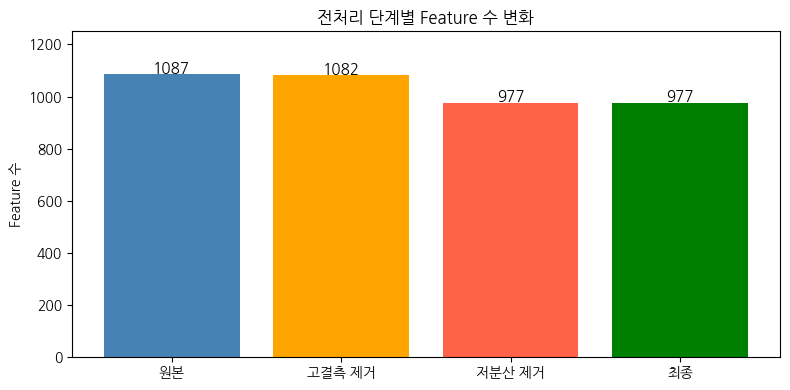

In [4]:
# feature 수 변화 시각화
removed_missing = len(report.get('high_missing', []))
removed_variance = len(report.get('constant', []))
counts = [
    len(feat_cols_raw),
    len(feat_cols_raw) - removed_missing,
    len(feat_cols_raw) - removed_missing - removed_variance,
    len(feat_cols),
]
labels = ['원본', '고결측 제거', '저분산 제거', '최종']
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, counts, color=['steelblue','orange','tomato','green'])
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(cnt), ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Feature 수')
ax.set_title('전처리 단계별 Feature 수 변화')
ax.set_ylim(0, max(counts)*1.15)
plt.tight_layout()
plt.show()

## Phase 0-5. Train/Val 분포 일치 검증 (추가)
- 전처리 후 train과 val의 feature 분포가 일치하는지 확인
- 스케일링이 train 기준이므로 val에 적용 시 분포 이동 없는지 검증
- 분포 불일치 시 모델 일반화 성능 저하 가능

Train/Val 평균 차이 > 0.1 std: 0개 / 977개
평균 차이 (std 단위): 0.0073
최대 차이 (std 단위): 0.0311 (X1014)


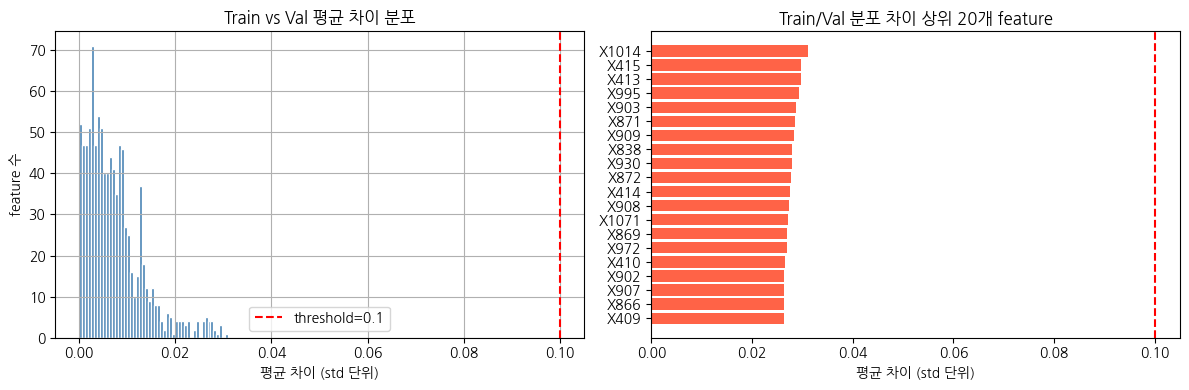

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.config import SPLIT_COL

train_xs = xs[xs[SPLIT_COL] == "train"][feat_cols]
val_xs   = xs[xs[SPLIT_COL] == "validation"][feat_cols]

# feature별 train/val 평균 차이
mean_diff = (val_xs.mean() - train_xs.mean()).abs()
std_train = train_xs.std().clip(lower=1e-8)
normalized_diff = mean_diff / std_train  # std 단위로 정규화

large_shift = (normalized_diff > 0.1).sum()
print(f"Train/Val 평균 차이 > 0.1 std: {large_shift}개 / {len(feat_cols)}개")
print(f"평균 차이 (std 단위): {normalized_diff.mean():.4f}")
print(f"최대 차이 (std 단위): {normalized_diff.max():.4f} ({normalized_diff.idxmax()})")

# 분포 차이 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
normalized_diff.hist(bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axvline(0.1, color="red", linestyle="--", label="threshold=0.1")
axes[0].set_xlabel("평균 차이 (std 단위)")
axes[0].set_ylabel("feature 수")
axes[0].set_title("Train vs Val 평균 차이 분포")
axes[0].legend()

# 차이 큰 상위 20개 feature
top20 = normalized_diff.nlargest(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color="tomato")
axes[1].axvline(0.1, color="red", linestyle="--")
axes[1].set_xlabel("평균 차이 (std 단위)")
axes[1].set_title("Train/Val 분포 차이 상위 20개 feature")
plt.tight_layout()
plt.show()

> **결론 — D. Train/Val 분포 일치 검증**
>
> 977개 feature 전부 평균 차이 < 0.1 std (최대 0.031 std, X1014). Train 기준으로 fit한 스케일러를 Val에 적용했는데도 분포 이동이 없었다. 전처리가 누수 없이 올바르게 적용됨.

## 2. 모듈 Import

In [6]:
# EDA 분석 모듈 import (19개)
import os
for _p in ['.', os.path.join(PROJECT_ROOT, '1_eda')]:
    if os.path.isdir(os.path.join(_p, 'modules')) and _p not in sys.path:
        sys.path.insert(0, _p)

from modules import eda_overview as ov
from modules import eda_feature_quality as fq
from modules import eda_outlier_scale as out
from modules import eda_outlier_methods as om
from modules import eda_relationships as rel
from modules import eda_nonlinear as nl
from modules import eda_interaction as ia
from modules import eda_group_compare as gc
from modules import eda_zero_structure as zs
from modules import eda_target_segment as ts
from modules import eda_dimreduce as dr
from modules import eda_wafer_map as wm
from modules import eda_wafer_pattern as wp
from modules import eda_lot_wafer as lw
from modules import eda_timeseries as tss
from modules import eda_lot_normalize as ln
from modules import eda_position as pos
from modules import eda_spatial as sp
from modules import eda_spatial_residual as sr
from modules import eda_neighbor_die as nd
from modules import eda_agg_compare as agg

print("19개 EDA 모듈 로드 완료")

19개 EDA 모듈 로드 완료


---
# Phase 1: 데이터 기본 파악
모듈: `eda_overview` (ov)

## 3. 데이터 구조 확인
- Xs: die-level wafer test data (die 단위 행)
- Ys: unit-level health data (unit 단위 행)
- 하나의 unit(ufs_serial)에 여러 die(run_wf_xy)가 매핑됨

In [7]:
# Xs 데이터 기본 정보: shape, dtypes, 메타 컬럼 샘플, feature 기초통계
ov.describe_xs(xs, feat_cols)

shape: (174572, 981)

dtypes:
float64    977
object       3
int64        1
Name: count, dtype: int64

메타 컬럼 샘플:
  ufs_serial         run_wf_xy  position       split
0     S00000  0000000_25_24_25         1       train
1     S00001  0000000_10_41_30         1        test
2     S00002   0000000_8_37_24         1       train
3     S00003  0000000_13_34_27         1       train
4     S00004  0000000_10_22_15         1       train
5     S00005  0000000_10_28_18         1  validation
6     S00006  0000000_11_52_14         1  validation
7     S00007   0000000_5_43_12         1  validation
8     S00008   0000000_6_26_14         1  validation
9     S00009   0000000_7_41_19         1       train

Feature 통계 (일부):
               X0          X1          X2          X3          X4          X5  \
count  174572.000  174572.000  174572.000  174572.000  174572.000  174572.000   
mean        0.297       0.309       0.302       0.320       0.999       1.199   
std         0.426       0.422       0.426   

count    43643.0
mean         4.0
std          0.0
min          4.0
25%          4.0
50%          4.0
75%          4.0
max          4.0
dtype: float64

고유 unit 수: 43,643
고유 die 수:  174,572


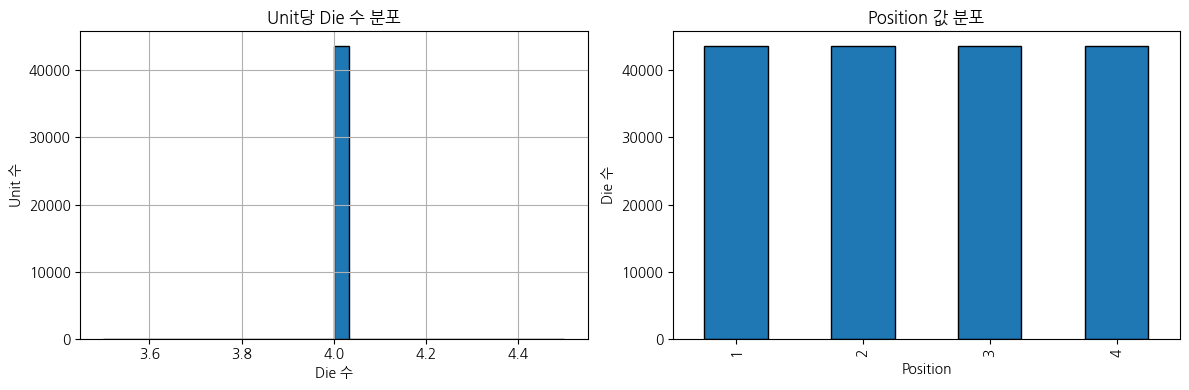

In [8]:
# unit당 die 수 분포 + position 균등 분포 확인
ov.plot_dies_per_unit(xs)

> **결론 — 3. 데이터 구조 확인**
>
> 모든 unit이 정확히 4개 die로 구성, split 60:20:20 균등. 완전 중복 컬럼 쌍 55개 발견 — 전처리 파이프라인에서 제거되지 않았으므로 Feature Selection 전 별도 제거 필요.

In [ ]:
# train / validation / test split 비율 (die + unit 레벨)
ov.print_split_ratio(xs, ys_all)

Xs (die level)
split
train         104748
test           34916
validation     34908
Name: count, dtype: int64
split
train         60.0
test          20.0
validation    20.0
Name: count, dtype: float64

Ys (unit level)
split
train         26187
test           8729
validation     8727
Name: count, dtype: int64
split
train         60.0
test          20.0
validation    20.0
Name: count, dtype: float64


## 4. Target 변수 (health) 분석
- Zero-inflated 분포: Y=0 약 70.8%, Y>0 약 29.2%
- 평가 지표: RMSE

count    43643.000000
mean         0.002531
std          0.007912
min          0.000000
25%          0.000000
50%          0.000000
75%          0.002273
max          1.000000
Name: health, dtype: float64

Y = 0 비율: 70.8%
Y > 0 비율: 29.2%


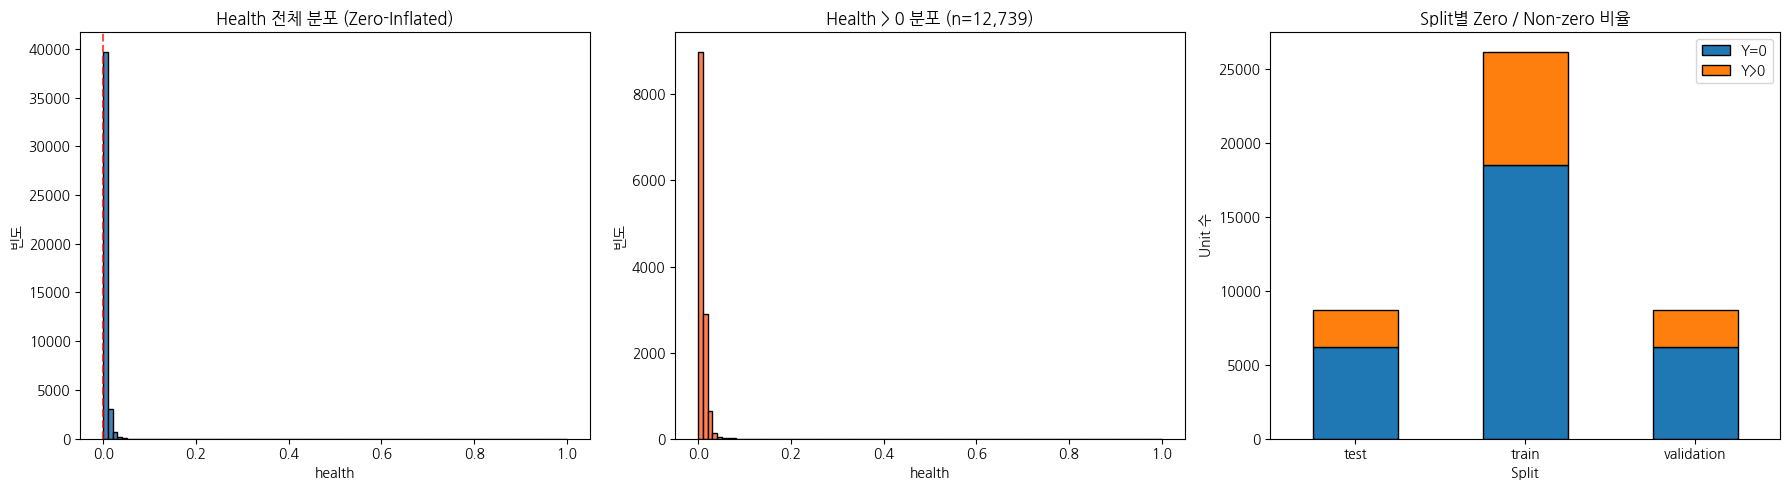

In [10]:
# Target(health) 분포 시각화: 전체/Y>0 분포, split별 zero/non-zero 비율
ov.plot_target_distribution(ys_all)

> **결론 — 4. Target 변수 분석**
>
> Y=0 비율 70.8%, Y>0 비율 29.2%로 zero-inflated 분포. Y>0일 때 대부분 0~0.015 구간에 밀집. Train/Val/Test 모두 동일 비율로 stratified split 확인됨.

---
# Phase 2: Feature 품질 검사
모듈: `eda_feature_quality` (fq)

## 6. Feature 분포 분석
- X0~X1086: 연속형 + 이산형 혼합 (고유값 ≤20 -> 이산형)

연속형 feature: 540개
이산형 feature: 437개 (고유값 수 20)


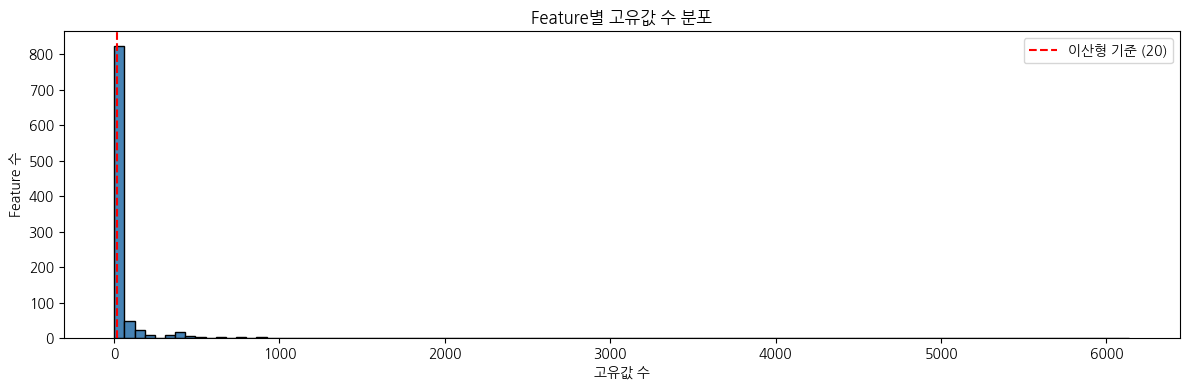


이산형 Feature 고유값 수:
X1082     1
X384      1
X375      1
X374      1
X620      1
         ..
X116     20
X137     20
X72      20
X74      20
X75      20
Length: 437, dtype: int64


In [11]:
# 연속형/이산형 자동 분류 + 고유값 수 분포
continuous_feats, discrete_feats = fq.classify_features(xs, feat_cols)

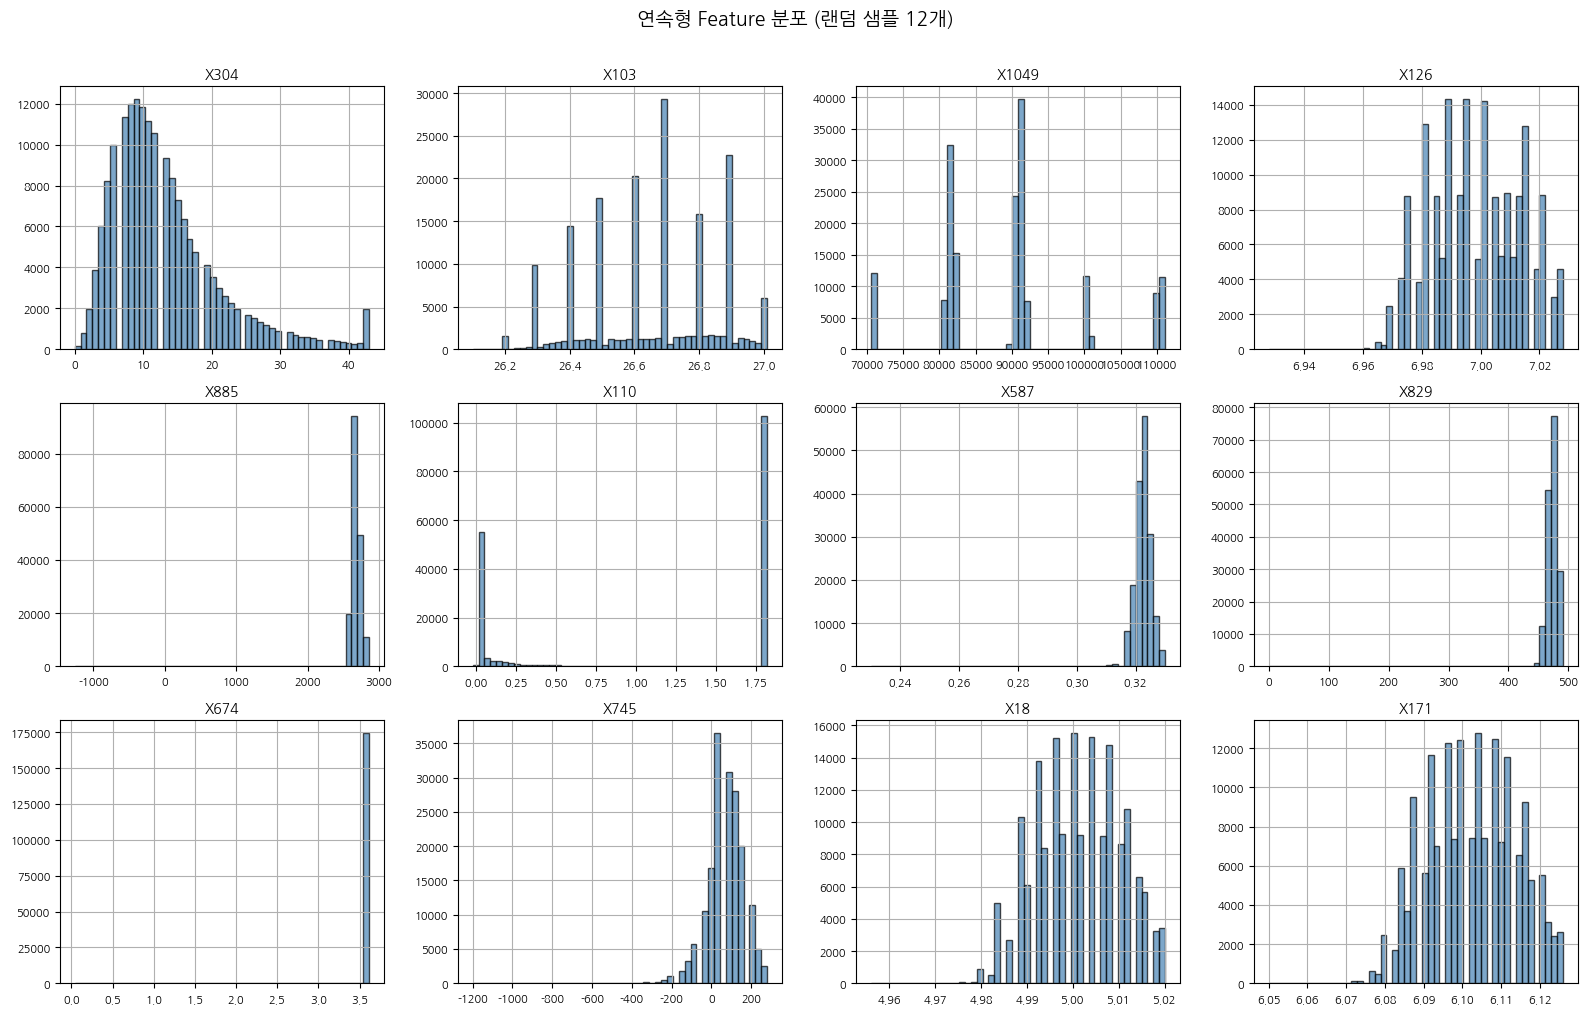

In [12]:
# 연속형 feature 랜덤 12개 히스토그램
fq.plot_continuous_dist(xs, continuous_feats)

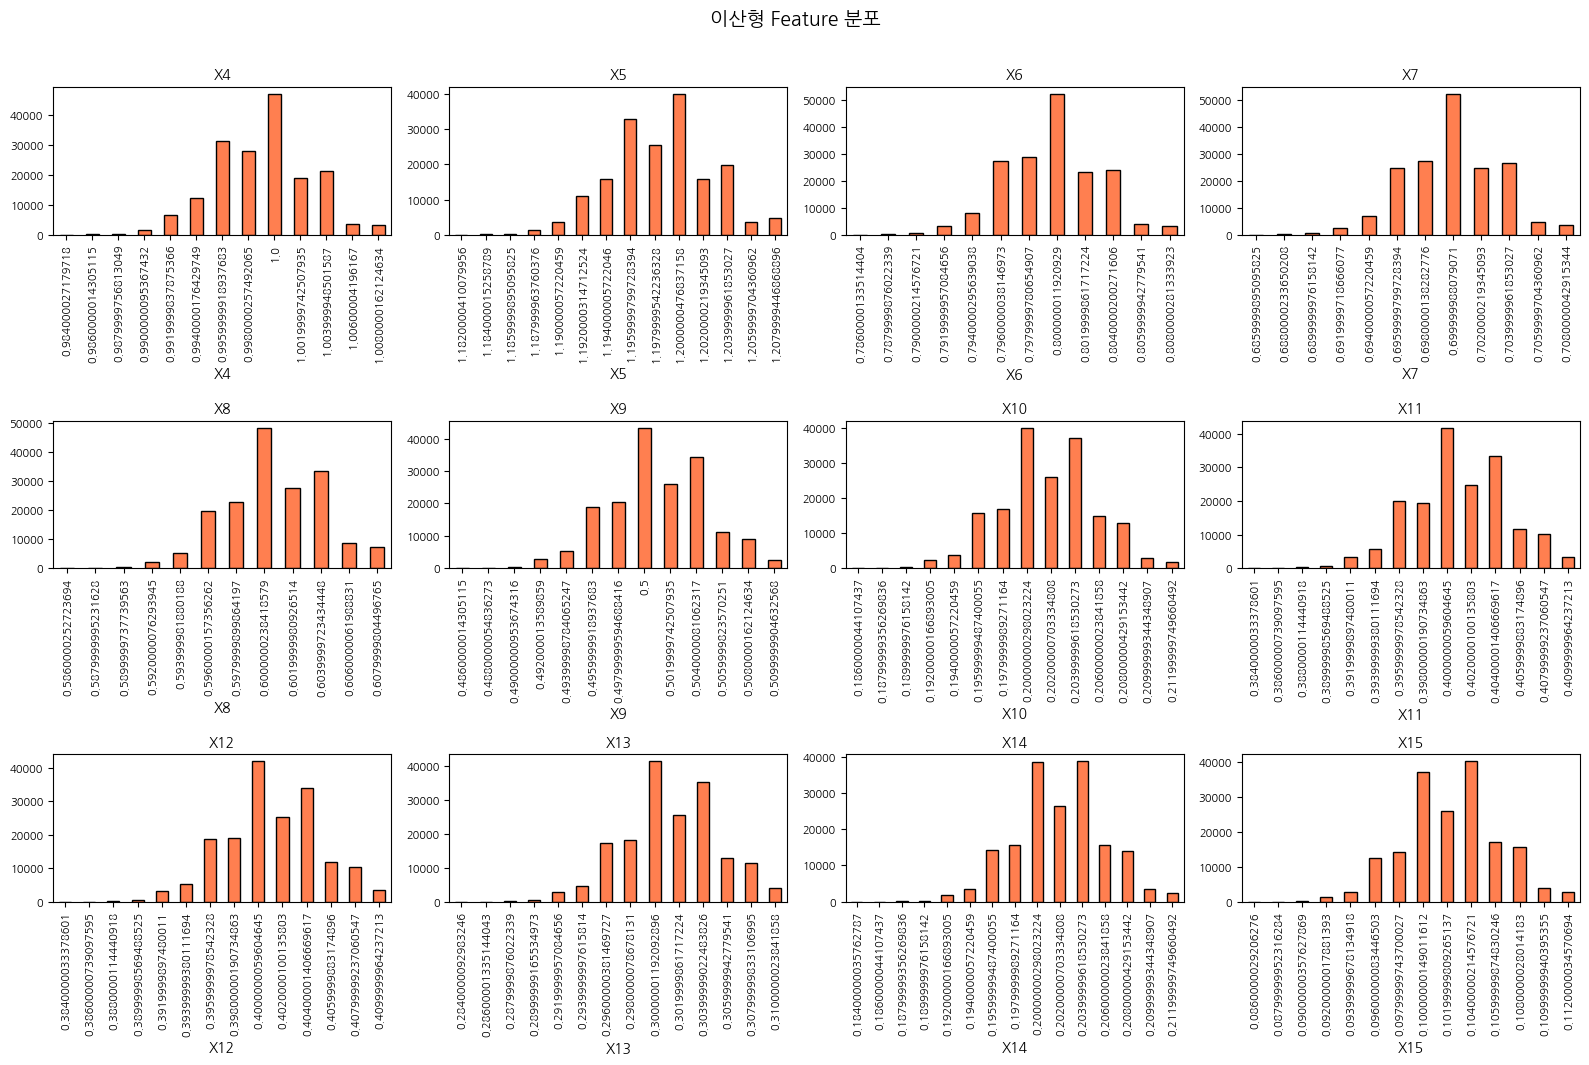

In [13]:
# 이산형 feature 최대 12개 값 분포 (bar chart)
fq.plot_discrete_dist(xs, discrete_feats)

## 7. 분산 분석 및 중복/상수 Feature 탐지

상수 feature (std=0): 6개
극저분산 feature (std<1e-6): 6개

상수 features: ['X374', 'X375', 'X384', 'X512', 'X620', 'X1082']

중복 컬럼 탐색 (샘플 기반):
완전 중복 컬럼 쌍: 55개
  X303 == X304
  X303 == X609
  X303 == X610
  X304 == X609
  X304 == X610
  X305 == X325
  X305 == X634
  X307 == X612
  X311 == X614
  X313 == X617
  ... 외 45개


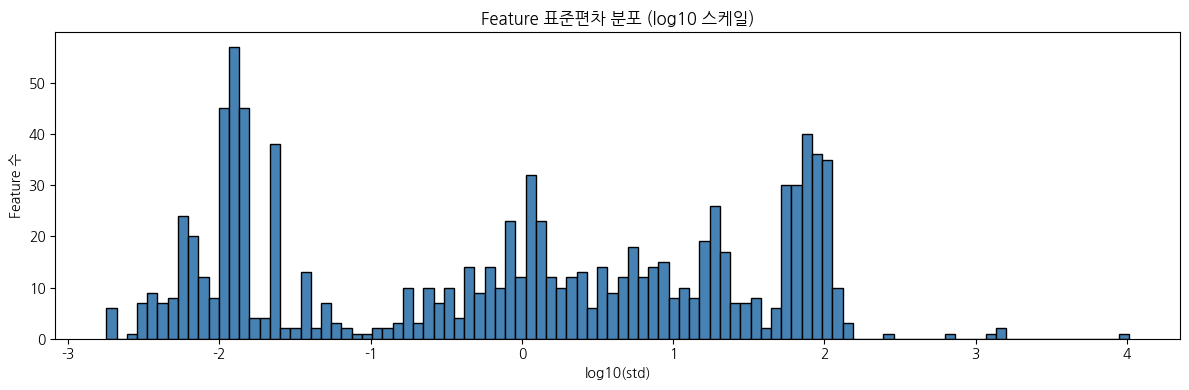

In [14]:
# 상수(std=0), 극저분산(std<1e-6), 완전 중복 컬럼 탐지
const_feats, low_var_feats, dup_pairs = fq.detect_low_variance(xs, feat_cols)

> **결론 — 7. 분산 분석 및 중복/상수 Feature 탐지**
>
> 전처리 후에도 상수 feature 6개, 완전 중복 쌍 55개 잔존. 전처리 파이프라인의 제거 기준(std<1e-6)과 EDA 기준(std=0)이 달라 일부가 남아있음. 모델 투입 전 추가 제거 필요.

---
# Phase 3: 이상치 및 스케일
모듈: `eda_outlier_scale` (out), `eda_outlier_methods` (om)

## 8. IQR 이상치 탐지 & 스케일 분석

이상치 비율 > 5% Feature: 173개
이상치 비율 > 10% Feature: 67개

이상치 비율 상위 20개:
X393    45.76
X988    40.51
X989    36.61
X976    32.62
X720    30.92
X950    28.54
X484    27.91
X971    27.15
X492    26.93
X485    26.88
X493    26.79
X483    26.31
X496    26.13
X914    25.40
X951    24.91
X491    24.53
X924    23.05
X915    21.44
X937    20.79
X975    20.70
dtype: float64


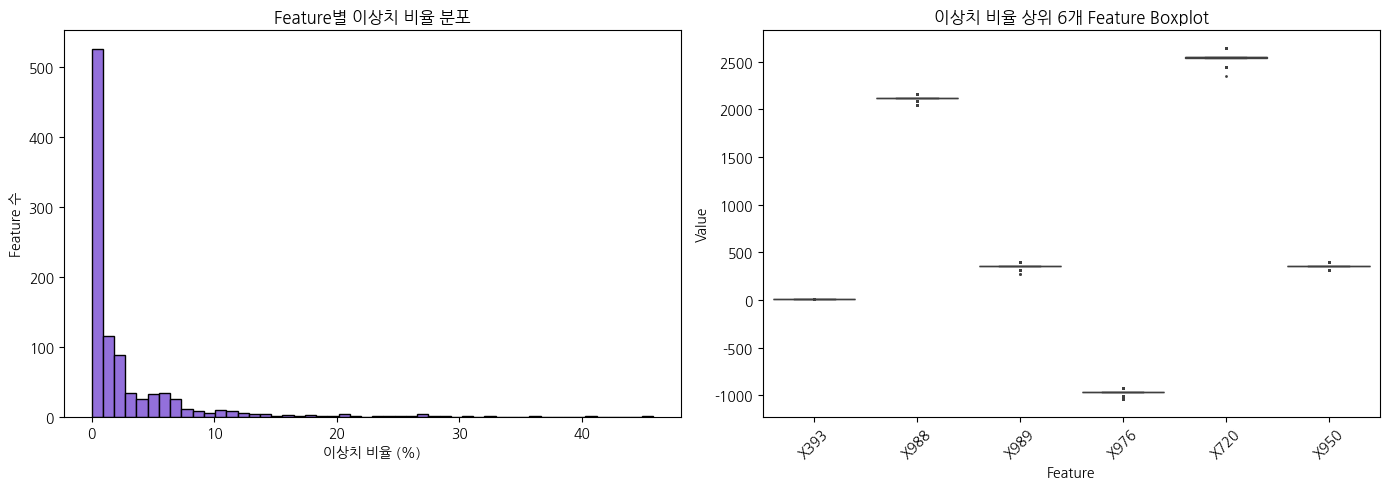

In [15]:
# IQR 기준 이상치 비율 분포 + 상위 6개 feature boxplot
out.plot_outlier_ratio(xs, feat_cols)

mean 범위:  [-2292.9685, 20201108.8805]
std 범위:   [0.0000, 10292.2096]
range 범위: [0.0000, 40702.5300]

왜도(skewness):
  |skew| > 2: 179개
  |skew| > 5: 89개


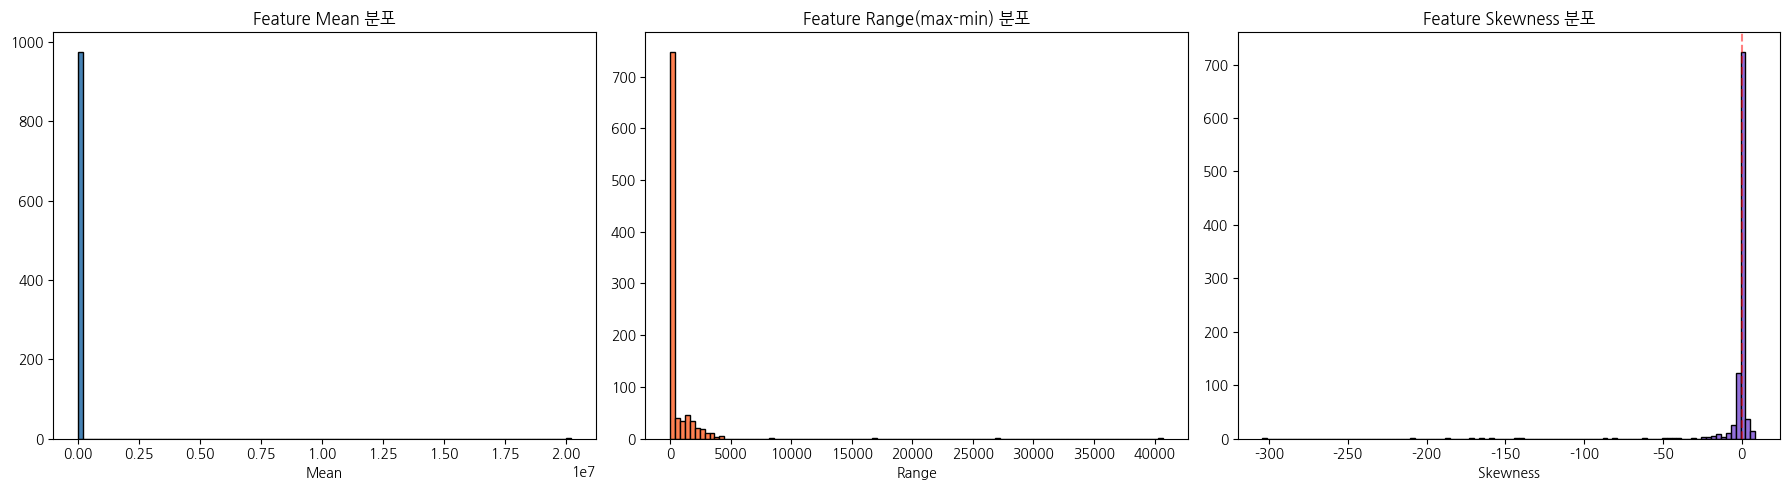

In [16]:
# feature 스케일 불균형: mean, range, skewness 분포
out.plot_scale_analysis(xs, feat_cols)

> **결론 — 8. IQR 이상치 탐지 & 스케일 분석**
>
> 이상치 비율 >5%: 173개, >10%: 67개. X393(45.8%), X988(40.5%), X989(36.6%) 최상위. clip(99%) 적용 후에도 mean 범위가 천만 단위(최대 ~2천만)로 잔존하는 feature 다수 — 분포 자체가 극단적으로 편향된 것. |skew|>2가 179개, |skew|>5가 89개로 여전히 다수.

## 9. Clip 결과 검증 (추가)
- Winsorization 적용 후 분포 확인
- clip 후 잔존 skewness 분포 파악 (스케일링 미적용)

clip 후 |skew|>2 feature: 179개 / 977개
clip 적용 feature (max > upper bound): 946개 / 977개


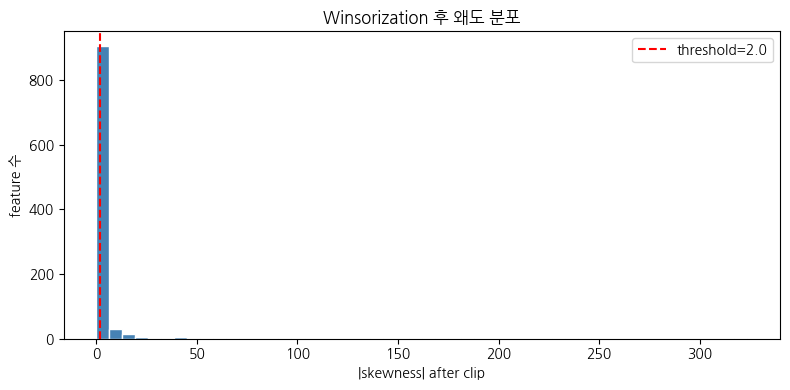

In [17]:
import matplotlib.pyplot as plt
import numpy as np

train_xs = xs[xs["split"] == "train"]
skew_after = train_xs[feat_cols].skew().abs()
still_high = (skew_after > 2.0).sum()
print(f"clip 후 |skew|>2 feature: {still_high}개 / {len(feat_cols)}개")

clipped_cnt = (clip_bounds["upper"] < xs_raw[feat_cols].max()).sum()
print(f"clip 적용 feature (max > upper bound): {clipped_cnt}개 / {len(feat_cols)}개")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(skew_after, bins=50, color="steelblue", edgecolor="white")
ax.axvline(2.0, color="red", linestyle="--", label="threshold=2.0")
ax.set_xlabel("|skewness| after clip")
ax.set_ylabel("feature 수")
ax.set_title("Winsorization 후 왜도 분포")
ax.legend()
plt.tight_layout()
plt.show()

> **결론 — A. Clip 결과 검증**
>
> 상위 99% Winsorization 적용 완료 — 977개 중 946개 feature에 clip 적용. clip 후에도 |skew|>2 잔존 179개. 트리 기반 파이프라인이므로 스케일링 없이 clip만으로 전처리 종료.

---
# Phase 4: Feature-Target 관계
모듈: `eda_relationships` (rel), `eda_nonlinear` (nl), `eda_interaction` (ia)

## 10. Pearson 상관관계
- die->unit 평균 집계 후 target과 비교
- 최대 |r| = 0.037 -> 단일 feature로는 예측 불가, 상호작용이 핵심

In [18]:
# Pearson 상관계수 계산 (train set만 사용)
train_merged, corr_with_target, corr_abs = rel.compute_correlation(xs_dict, ys_train, feat_cols)

Train merged shape: (26187, 979)

상관계수 상위 20개 Feature:
     X1083: -0.0374
      X739: +0.0367
      X769: +0.0366
      X881: -0.0341
     X1085: +0.0335
      X844: -0.0318
      X761: +0.0312
      X299: +0.0310
      X344: -0.0308
      X821: +0.0308
      X348: -0.0306
      X271: -0.0304
      X295: +0.0304
      X254: +0.0297
      X257: +0.0293
      X235: +0.0292
      X750: +0.0292
      X256: +0.0290
      X238: +0.0290
      X234: +0.0289


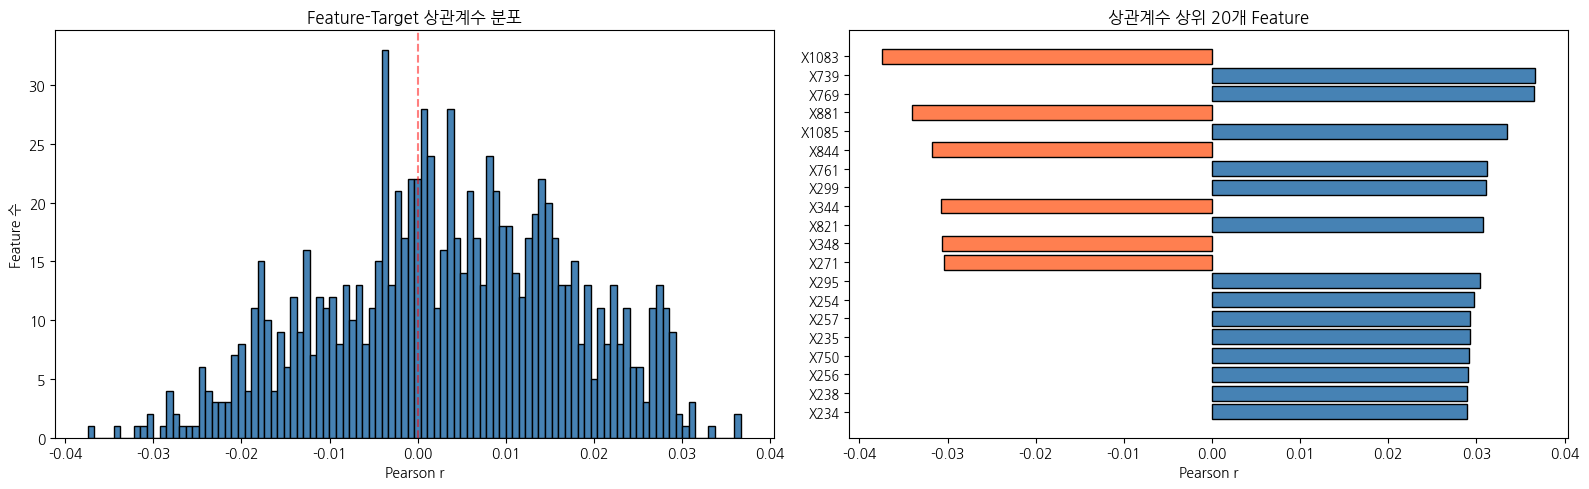

In [19]:
# 상관계수 분포 + 상위 20개 bar chart
rel.plot_corr_with_target(corr_with_target, corr_abs)

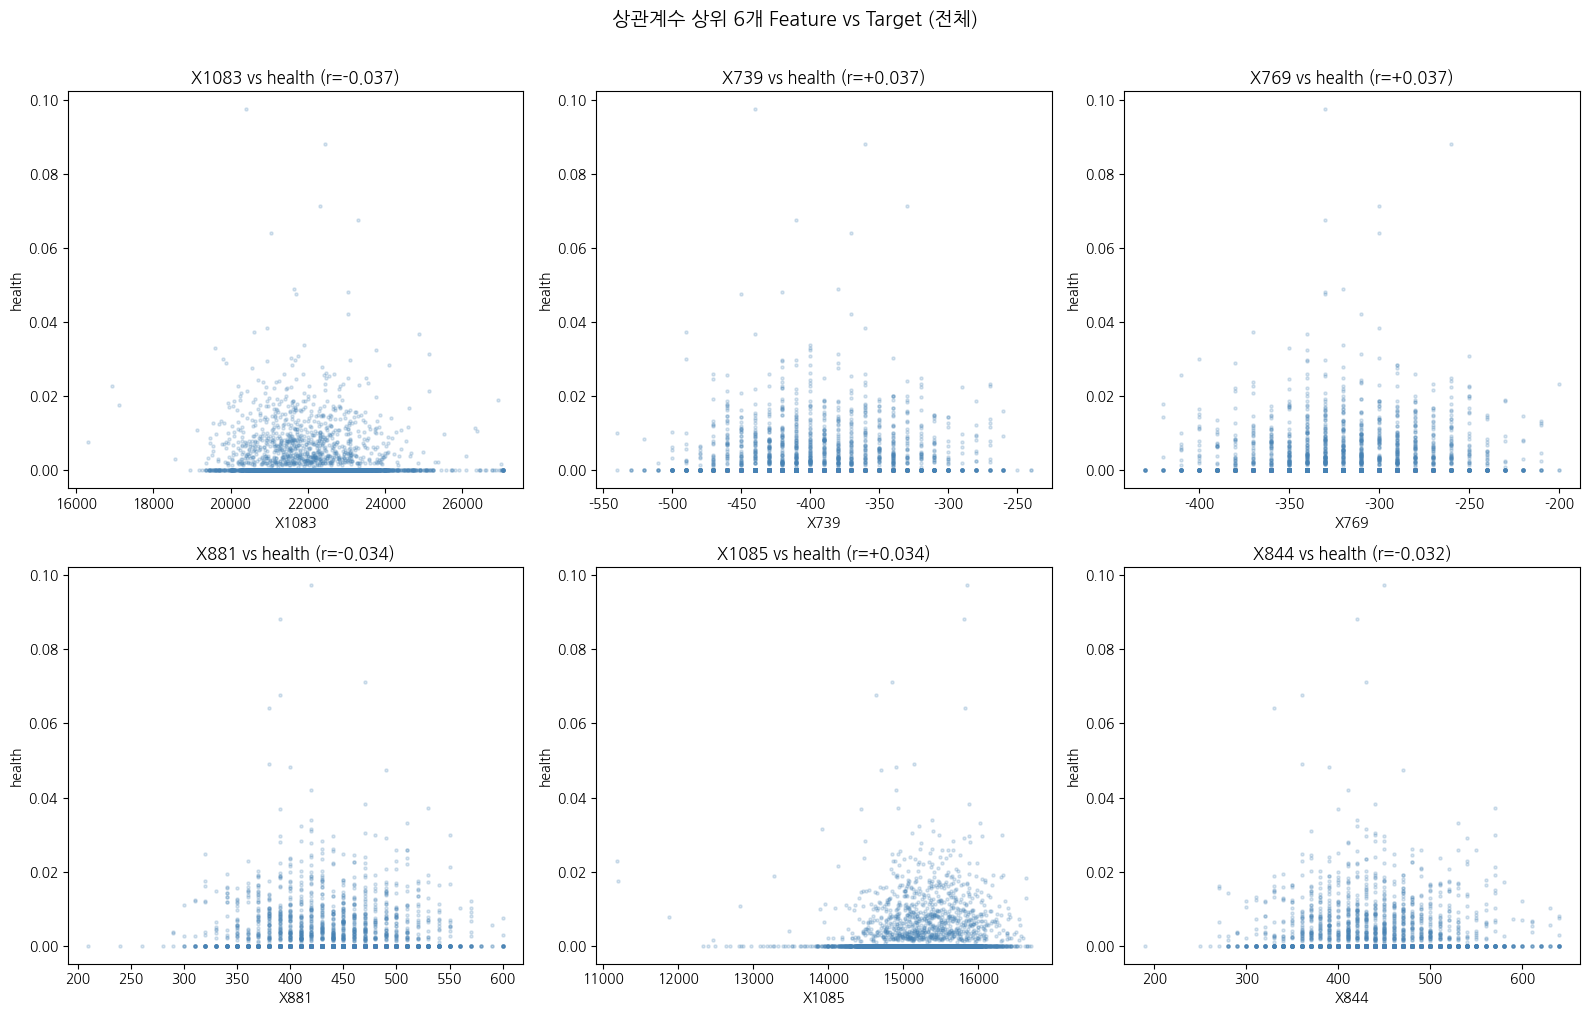

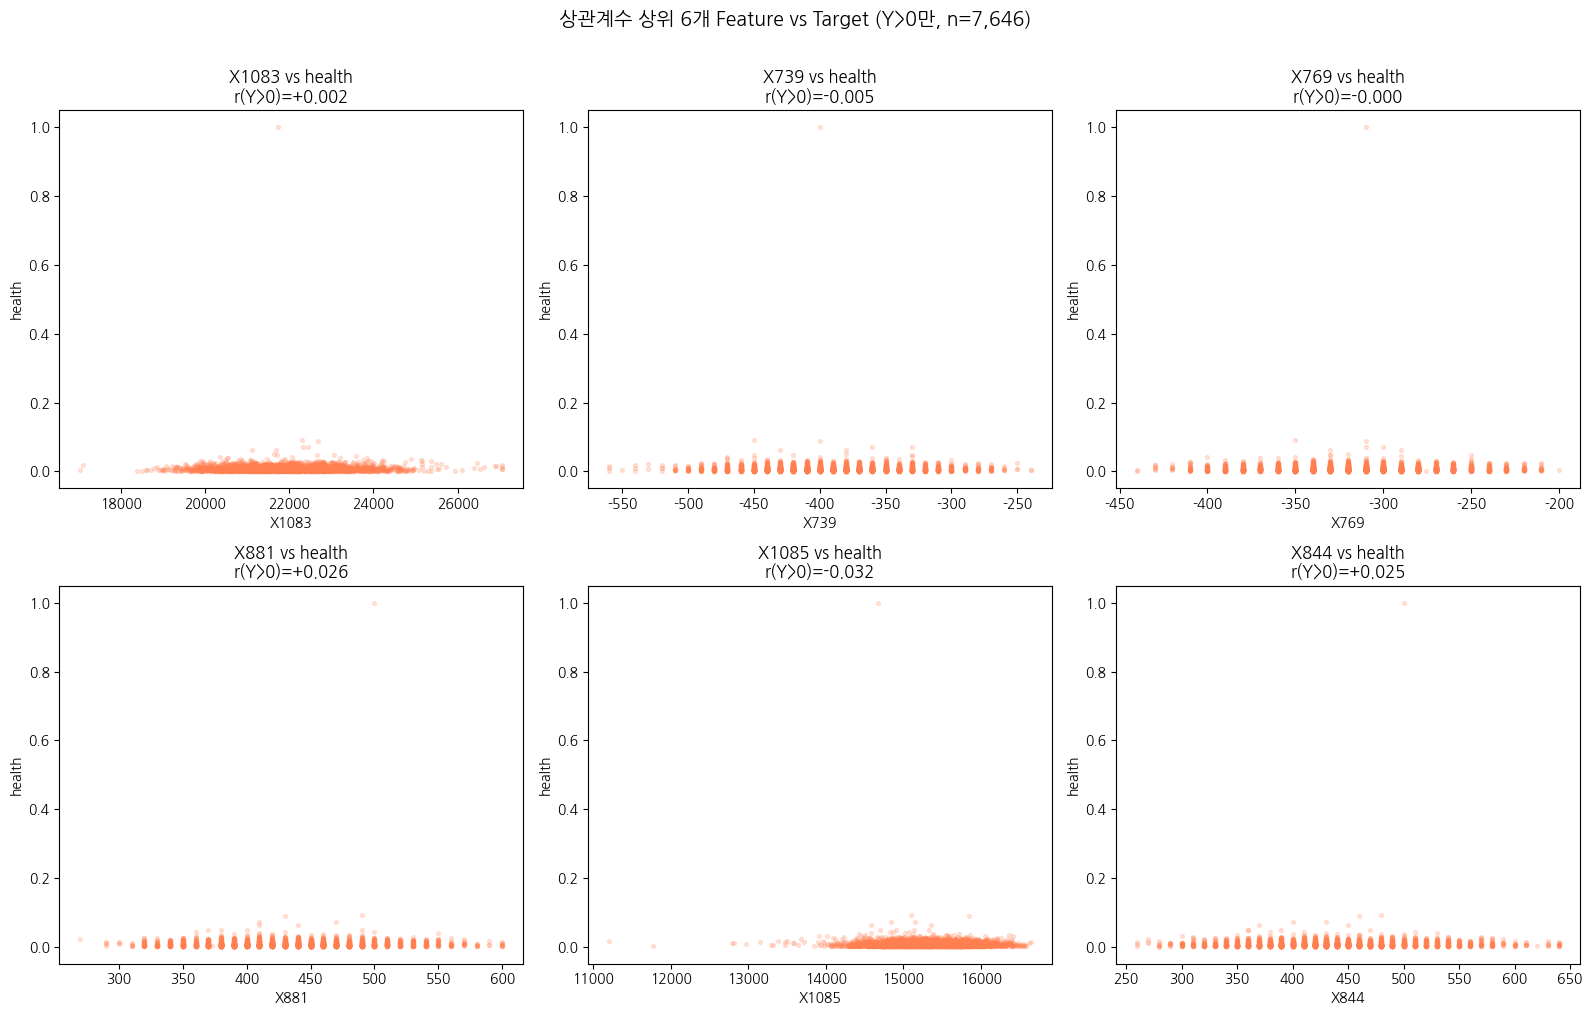

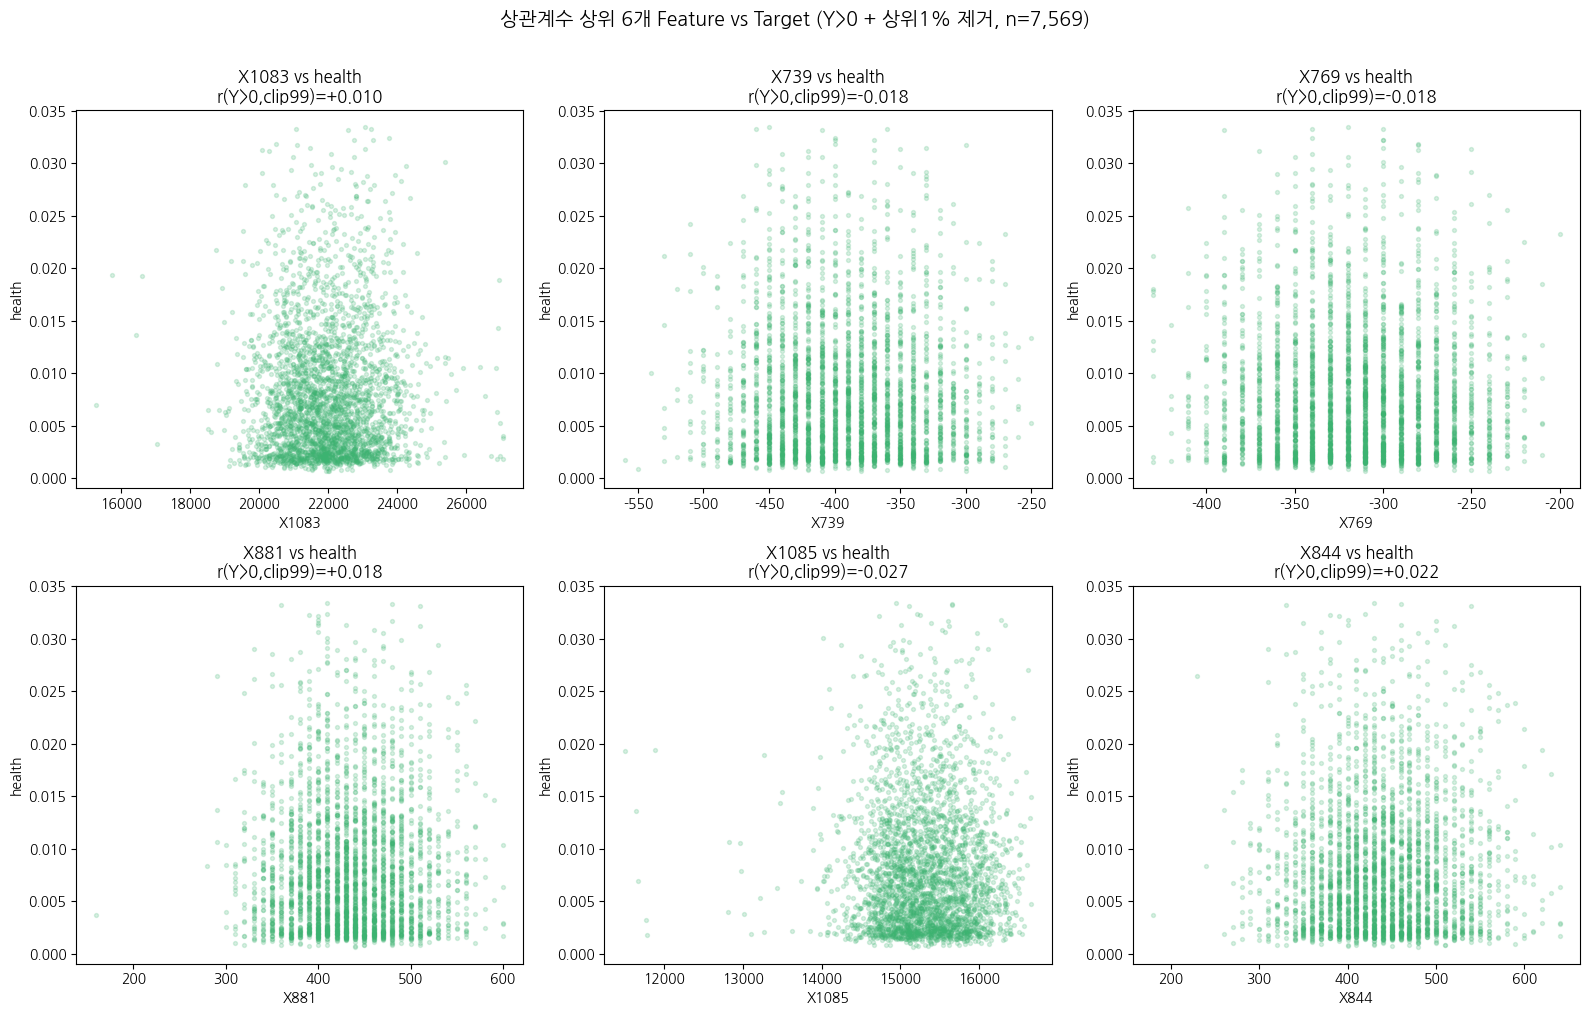


전체 vs Y>0 vs Y>0+clip99 상관계수 비교
  (전체: 26,187, Y>0: 7,646, Y>0+clip99: 7,569, 상위1% 기준: 0.0335)
     Feature       r(전체)      r(Y>0)   r(clip99)
--------------------------------------------------
       X1083     -0.0374     -0.0017     -0.0004
        X739     +0.0367     -0.0080     -0.0031
        X769     +0.0366     -0.0037     -0.0030
        X881     -0.0341     +0.0126     -0.0039
       X1085     +0.0335     -0.0180     -0.0141
        X844     -0.0318     +0.0110     +0.0021


In [20]:
# 상위 6개 feature vs health scatter plot
rel.plot_top_scatter(train_merged, corr_with_target, corr_abs)

> **결론 — 10. Pearson 상관관계**
>
> max|r| = 0.0374 (X1083), |r|>0.05인 feature 0개. 전처리 전(0.037)과 사실상 동일 — 전처리가 선형 신호를 만들지 않았다.
>
> **⭐ 전체 기준 top feature들이 Y>0 서브셋에서는 r≈0으로 수렴.** X1083: 전체 r=-0.037 → Y>0 서브셋 r=-0.002, X739: 전체 r=+0.037 → Y>0 r=-0.008. 전체 상관의 대부분이 "Y=0 vs Y>0 구분"에서만 발생하며, Y>0 내부 health 크기와는 무관한 피처들임. Stage 1(분류)과 Stage 2(회귀)에서 서로 다른 피처를 써야 한다.

## 10-1. 전처리 전후 Feature-Target 상관 변화 (추가)
- 원본 xs_raw vs 전처리 후 xs 기준 Pearson |r| 비교
- 전처리가 신호를 살렸는지 죽였는지 확인

전처리 후 상관 향상: 491개 (50.6%)
전처리 후 상관 악화: 447개 (46.0%)
평균 delta: 0.00016
원본 max|r|: 0.0372 -> 전처리 후: 0.0374


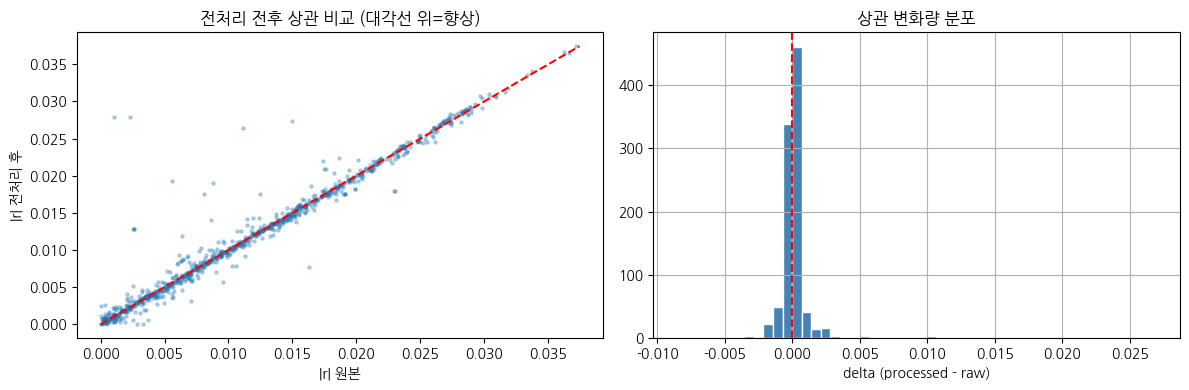

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from utils.config import KEY_COL, TARGET_COL, SPLIT_COL

raw_train = xs_raw[xs_raw[SPLIT_COL] == "train"]
raw_unit = raw_train.groupby(KEY_COL)[feat_cols].mean()
raw_merged = raw_unit.join(ys_train.set_index(KEY_COL)[TARGET_COL])
corr_raw = raw_merged.corr()[TARGET_COL].drop(TARGET_COL).abs()

proc_train = xs[xs[SPLIT_COL] == "train"]
proc_unit = proc_train.groupby(KEY_COL)[feat_cols].mean()
proc_merged = proc_unit.join(ys_train.set_index(KEY_COL)[TARGET_COL])
corr_proc = proc_merged.corr()[TARGET_COL].drop(TARGET_COL).abs()

compare_df = pd.DataFrame({"raw": corr_raw, "processed": corr_proc}).dropna()
compare_df["delta"] = compare_df["processed"] - compare_df["raw"]
improved = (compare_df["delta"] > 0).sum()
worse = (compare_df["delta"] < 0).sum()
print(f"전처리 후 상관 향상: {improved}개 ({improved/len(compare_df)*100:.1f}%)")
print(f"전처리 후 상관 악화: {worse}개 ({worse/len(compare_df)*100:.1f}%)")
delta_mean = compare_df["delta"].mean()
print(f"평균 delta: {delta_mean:.5f}")
print(f"원본 max|r|: {corr_raw.max():.4f} -> 전처리 후: {corr_proc.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mx = compare_df[["raw","processed"]].max().max()
axes[0].scatter(compare_df["raw"], compare_df["processed"], alpha=0.3, s=5)
axes[0].plot([0, mx], [0, mx], "r--")
axes[0].set_xlabel("|r| 원본")
axes[0].set_ylabel("|r| 전처리 후")
axes[0].set_title("전처리 전후 상관 비교 (대각선 위=향상)")
compare_df["delta"].hist(bins=50, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("delta (processed - raw)")
axes[1].set_title("상관 변화량 분포")
plt.tight_layout()
plt.show()

> **결론 — B. 전처리 전후 Feature-Target 상관 변화**
>
> 향상 50.6%, 악화 46.0%, 평균 delta=+0.00016, max|r| 0.0372→0.0374. 전처리 효과가 Pearson 상관에 중립적 — 향상도 악화도 미미했다. 신호 자체가 비선형이라 전처리로는 선형 상관이 올라가지 않음.

## 11. Feature 간 상관관계 (다중공선성)

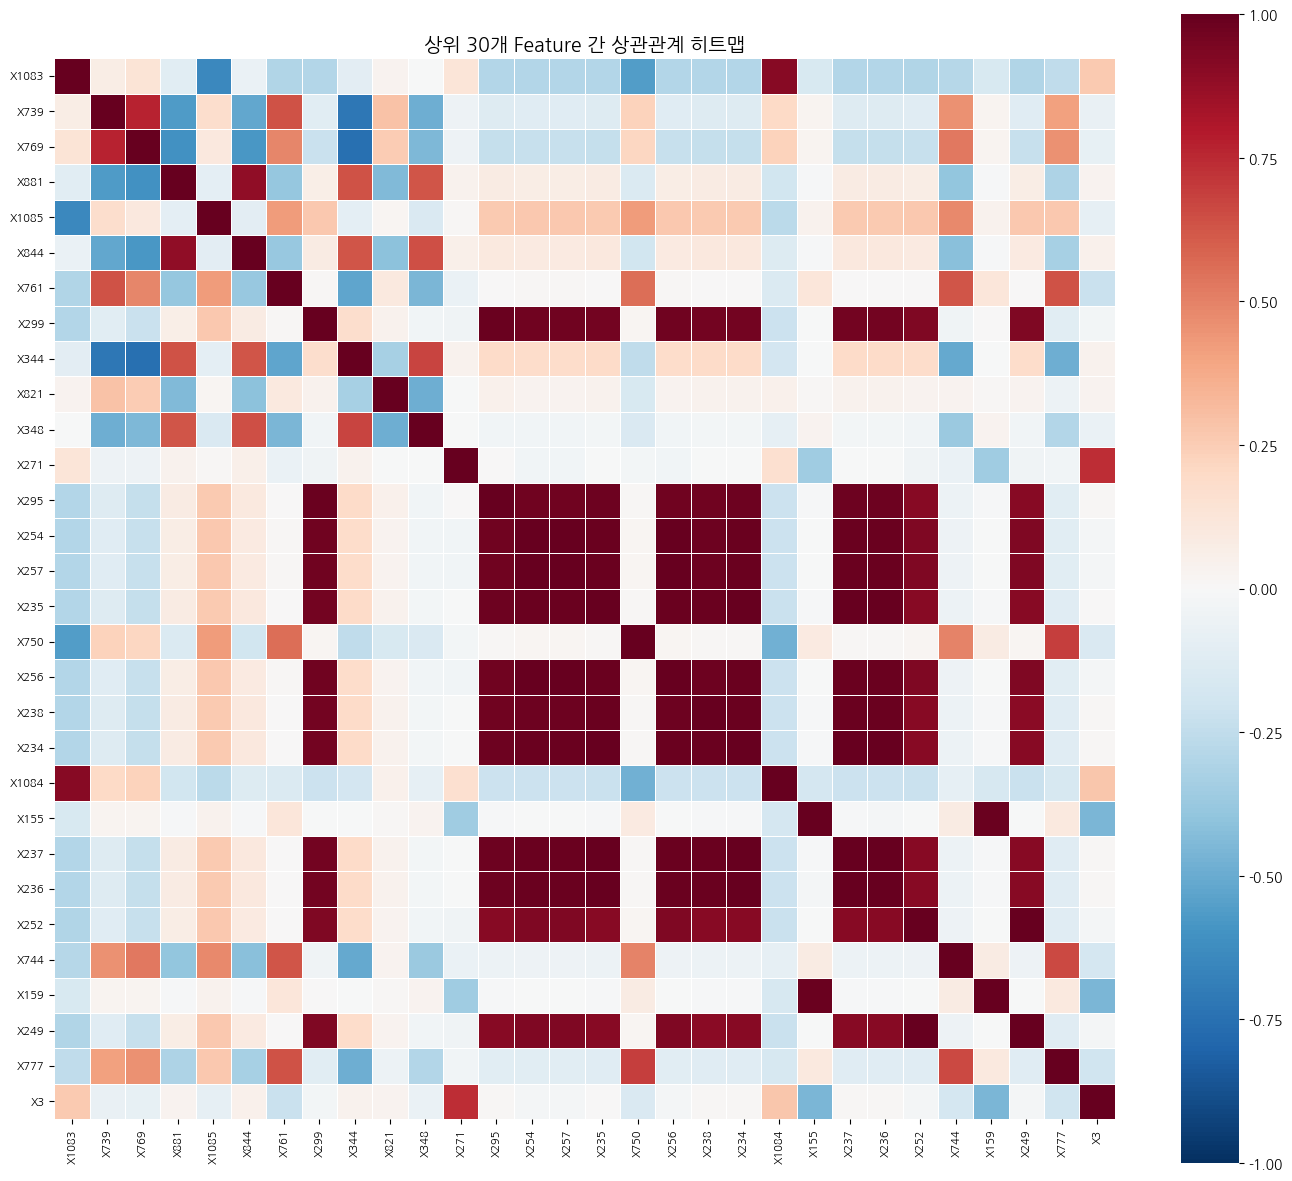

|r| > 0.95인 Feature 쌍: 47개
      X235 ↔ X234    : r=+0.9982
      X234 ↔ X236    : r=+0.9981
      X237 ↔ X236    : r=+0.9981
      X235 ↔ X236    : r=+0.9981
      X234 ↔ X237    : r=+0.9979
      X235 ↔ X237    : r=+0.9979
      X257 ↔ X256    : r=+0.9977
      X254 ↔ X256    : r=+0.9977
      X254 ↔ X257    : r=+0.9975
      X252 ↔ X249    : r=+0.9975
      X256 ↔ X236    : r=+0.9909
      X256 ↔ X237    : r=+0.9909
      X257 ↔ X237    : r=+0.9909
      X254 ↔ X236    : r=+0.9908
      X254 ↔ X234    : r=+0.9908


In [22]:
# 상위 30개 feature 상호 상관 히트맵 + |r|>0.95 쌍 출력
rel.plot_feature_heatmap(train_merged, corr_abs)

VIF 계산: 전체 977개 → 971개 대상
  제외: 결측>=50% 0개, 상수/극저분산 6개 | 나머지 결측은 median 대체 | 26,187행

  VIF > 10 (심각한 다중공선성): 651개
  VIF 5~10 (주의 필요):       39개
  VIF <= 5 (양호):            281개

VIF 상위 30개:
      X427: 1910823209230631384032531055750246652098975182618624.00 ★
      X420: 490362521565656767552102882218719062547248623648768.00 ★
      X325: 56586167696645710838000645198147234793271590912.00 ★
      X305: 2999452183211209658998552746131364117227765760.00 ★
      X303: 328849821989383261576414618490421379072.00 ★
      X421: 28895681662386927619292116540572303360.00 ★
      X356: 1468707829875679677511191944755150848.00 ★
      X324: 159831959919511464290790689545912320.00 ★
      X311: 464455308723387028241901756088320.00 ★
      X436: 151741885164402740789549671120896.00 ★
      X357: 84808166420739100147448513822720.00 ★
      X609: 17371138801600712454839468032.00 ★
      X635: 437357456774634917962186752.00 ★
      X417: 87037548659892634307788800.00 ★
      X358: 1495948623135231512

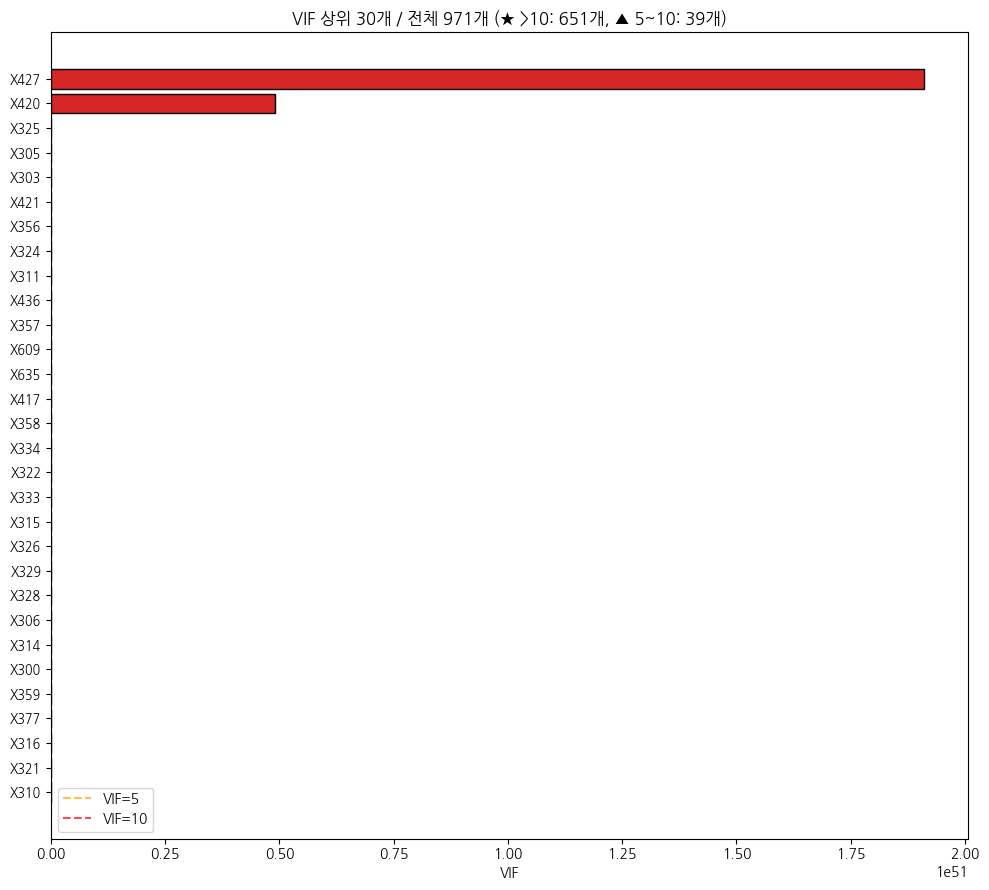

In [23]:
# VIF (Variance Inflation Factor) - 전체 feature 다중공선성 정량 검사
vif_df = rel.compute_vif(train_merged, feat_cols, top_n=30)

> **결론 — 11. Feature 간 상관관계 (다중공선성)**
>
> |r|>0.95 쌍: 47개. VIF>10: 651개/971개(67.0%). X427·X420 등은 VIF가 10^50을 초과해 사실상 발산(완전 중복 수준의 다중공선성). 다중공선성이 극심하여 선형 모델 계수 해석 불가. 트리 모델은 영향 없으나 Feature Selection으로 중복 피처 제거 필요.

## 13. 비선형 상관 분석 (Spearman + Mutual Information)

> 3가지 상관 분석 방법으로 feature-target 관계 비교
- Pearson: X가 올라가면 Y도 일정 비율로 올라가는 직선 관계를 봄
- Spearman: 비율 상관없이 X가 올라가면 Y도 올라가는지 방향만 봄
- MI: 직선이든 곡선이든 U자든 어떤 관계든 있으면 잡아냄

In [24]:
# Spearman + MI 계산 (train set)
result_df = nl.compute_nonlinear_corr(xs_dict, ys_train, feat_cols)
nl.print_nonlinear_summary(result_df)

Pearson 상관계수 계산 중...
Spearman 순위 상관계수 계산 중...
Mutual Information 계산 중 (n_neighbors=5)...
완료!
비선형 상관 분석 요약

          방법       max      mean    median       std
--------------------------------------------------
     pearson    0.0374    0.0116    0.0104    0.0082
    spearman    0.0874    0.0237    0.0215    0.0164
          mi    0.0288    0.0025    0.0012    0.0034

MI 상위 20개 Feature (+ Pearson/Spearman 랭킹 비교)
   Feature        MI    MI순위    Pearson     P순위   Spearman     S순위     순위차
---------------------------------------------------------------------------
     X1066    0.0288       1    +0.0066     636    +0.0294     325    +635
     X1060    0.0245       2    -0.0123     427    -0.0293     326    +425
     X1071    0.0221       3    -0.0065     644    -0.0125     670    +641
     X1068    0.0217       4    +0.0056     674    +0.0228     457    +670
     X1064    0.0214       5    -0.0032     804    -0.0004     968    +799
     X1067    0.0202       6    -0.0005     944    -0.0038

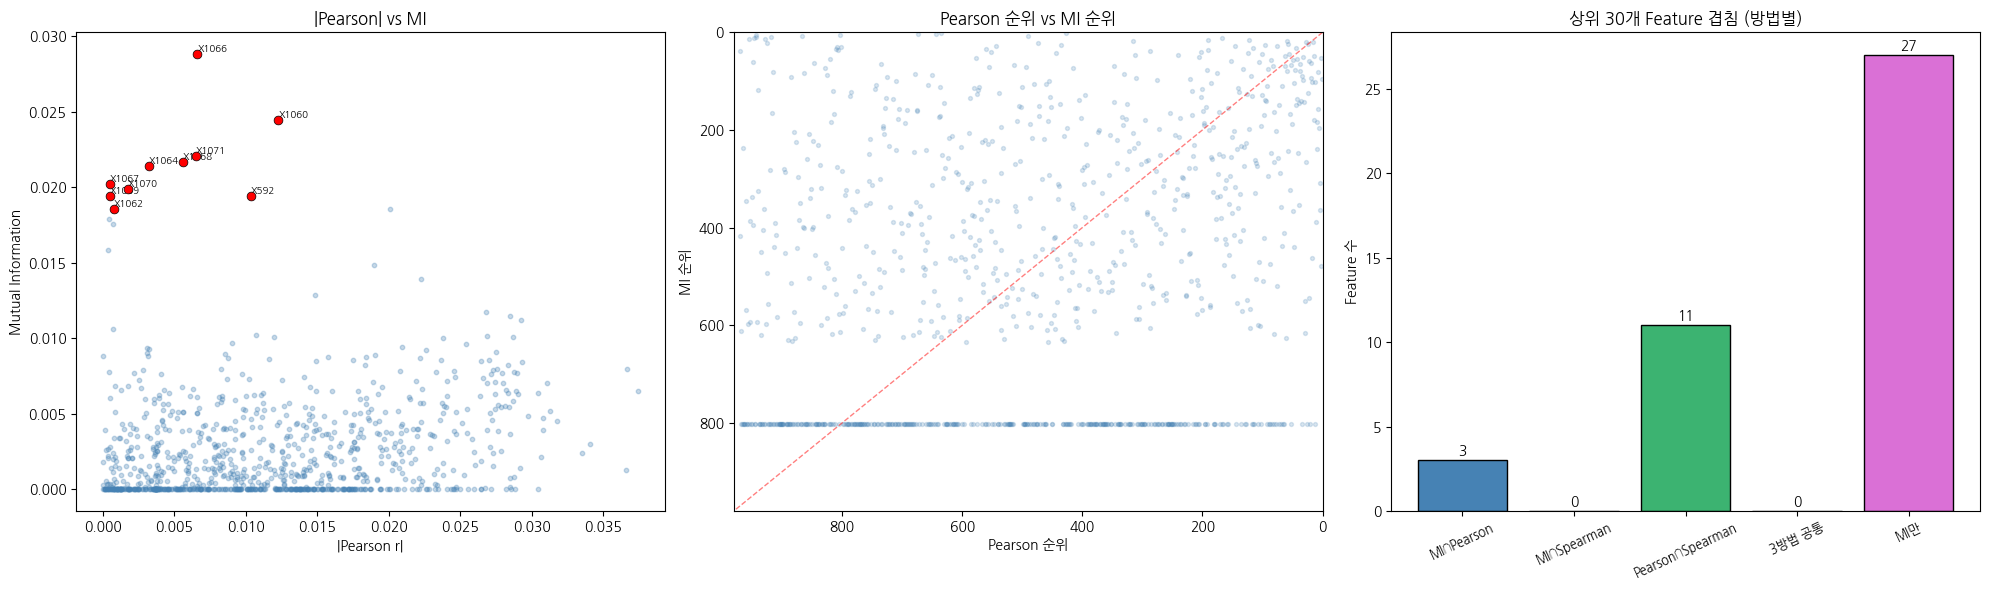


상위 30개 겹침 분석:
  MI ∩ Pearson    : 3/30
  MI ∩ Spearman   : 0/30
  Pearson ∩ Spearman : 11/30
  3방법 공통       : 0/30
  MI에서만 상위    : 27/30  ← Pearson이 놓친 비선형 feature


In [25]:
# Pearson vs Spearman vs MI 순위 비교 scatter
nl.plot_rank_comparison(result_df)

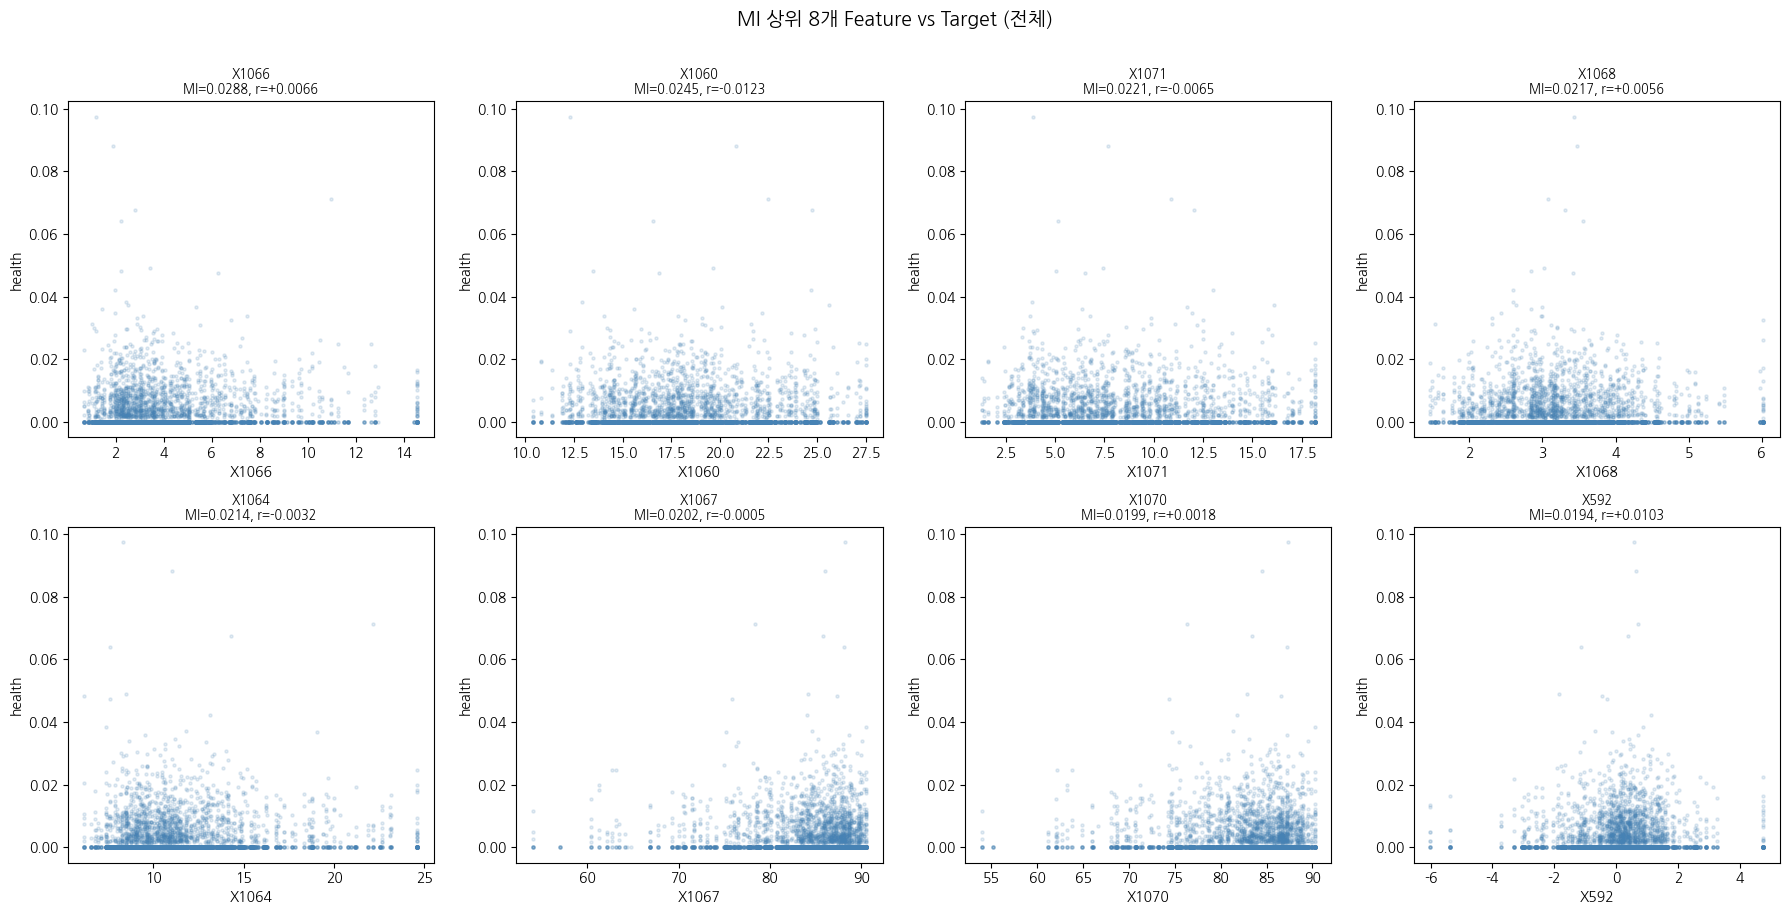

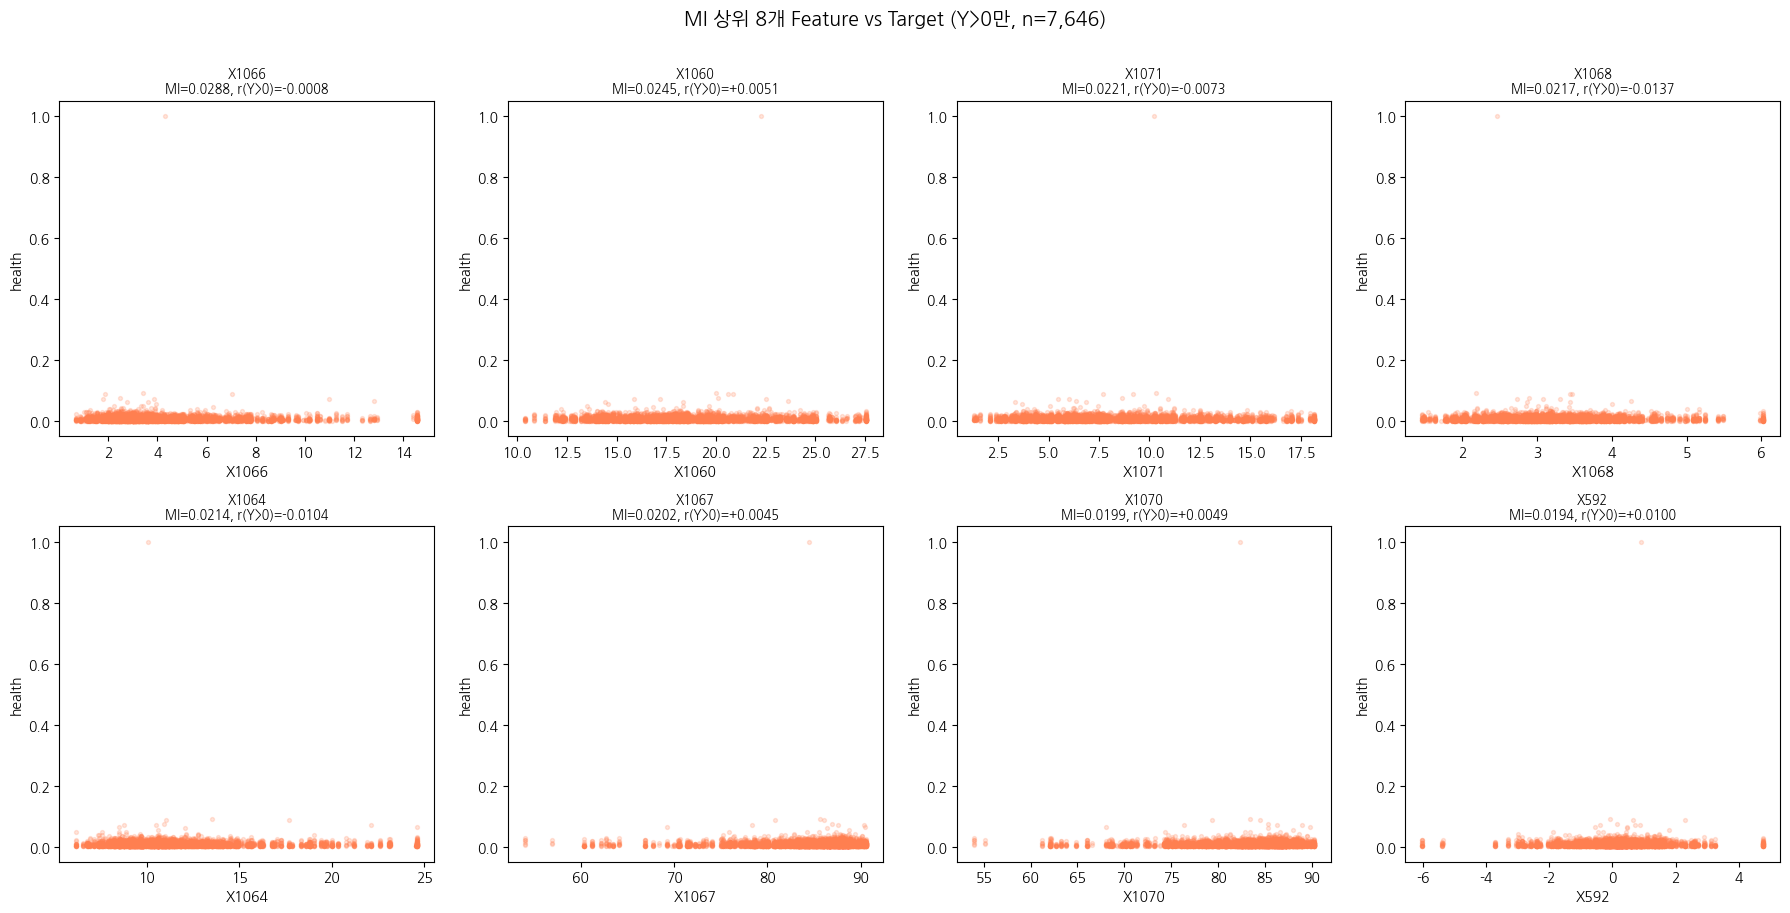

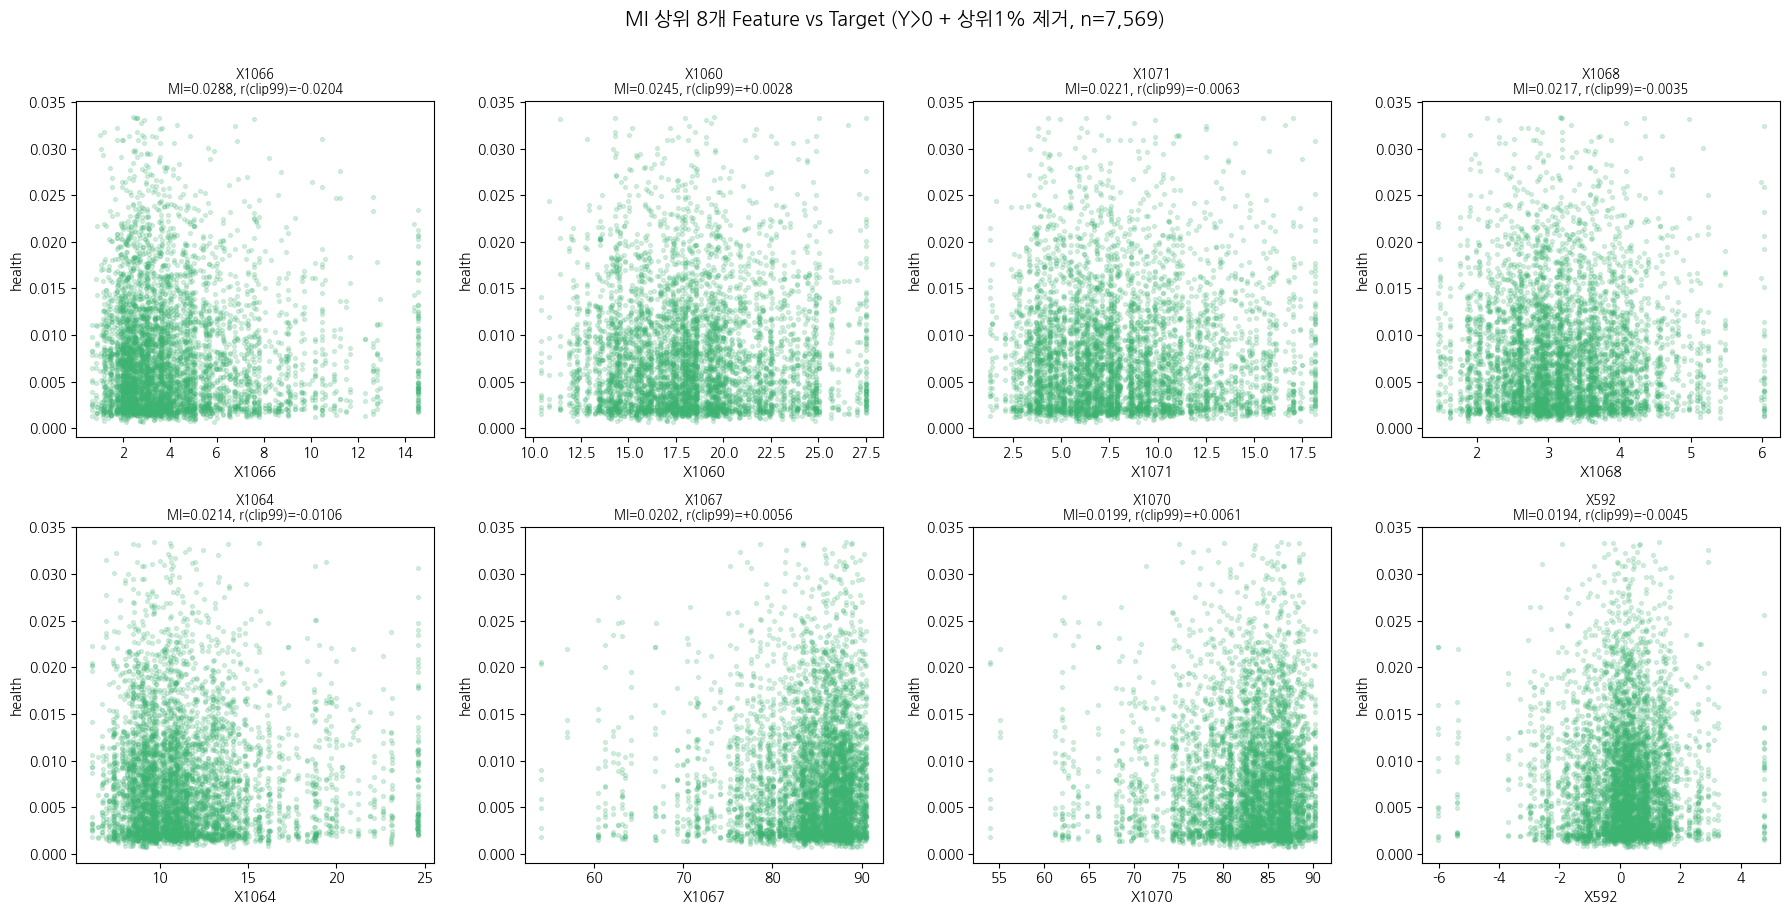


전체 vs Y>0 vs Y>0+clip99 상관계수 비교
  (전체: 26,187, Y>0: 7,646, Y>0+clip99: 7,569, 상위1% 기준: 0.0335)
     Feature       r(전체)      r(Y>0)   r(clip99)
--------------------------------------------------
       X1066     +0.0066     -0.0096     -0.0098
       X1060     -0.0123     +0.0039     -0.0128
       X1071     -0.0065     -0.0056     -0.0142
       X1068     +0.0056     -0.0073     +0.0024
       X1064     -0.0032     -0.0133     -0.0132
       X1067     -0.0005     +0.0098     +0.0080
       X1070     +0.0018     +0.0100     +0.0101
        X592     +0.0103     +0.0079     -0.0008


In [26]:
# MI 상위 feature의 scatter plot (비선형 패턴 확인)
nl.plot_mi_top_scatter(xs_dict, ys_train, feat_cols, result_df)

> **결론 — 13. 비선형 상관 분석 (Spearman + Mutual Information)**
>
> Spearman max|r|=0.087 — Pearson(0.037)의 2.3배. 비선형 단조 관계가 실재한다.
>
> **⭐ MI top 30 ∩ Pearson top 30: 3개(10%). MI top 30 ∩ Spearman top 30: 0개.** 세 방법이 잡아내는 피처가 거의 완전히 다르다. Pearson만 쓰면 MI가 포착하는 비선형 신호의 90%를 놓친다 — Feature Selection에 3종 병행 필수.

---
# Phase 5: Target 심층 분석
모듈: `eda_group_compare` (gc), `eda_zero_structure` (zs), `eda_target_segment` (ts)

## 15. Y=0 vs Y>0 그룹 비교
- 70.8% vs 29.2% 그룹 간 WT feature 분포 차이 검정
- Mann-Whitney U, Cohen's d, KS 검정

In [27]:
# 그룹 개요: unit 수, feature 통계 요약
_, grp_zero, grp_pos = gc.group_overview(xs_dict, ys_train, feat_cols)

Y=0 vs Y>0 그룹 기초통계
전체 unit 수: 26,187
Y=0 (정상) : 18,541 (70.8%)
Y>0 (불량) : 7,646 (29.2%)

그룹 평균 차이가 큰 상위 10개 Feature:
   Feature   mean(Y=0)   mean(Y>0)        |차이|
--------------------------------------------------
     X1049  89876.8207  89015.4979    861.3228
     X1083  22172.6845  21954.3483    218.3363
     X1084  37370.2937  37259.0990    111.1947
     X1085  15189.4359  15299.5818    110.1459
      X744    -24.3051     -5.7481     18.5570
      X839   1427.6963   1412.1371     15.5592
      X376    385.2764    371.1767     14.0997
      X774   1561.6730   1575.3976     13.7245
      X740     34.7883     47.4889     12.7006
      X741     29.2762     41.4661     12.1899


통계 검정 요약
검정 대상 feature: 977개
Mann-Whitney U 유의 (p<0.05): 685개 (70.1%)
KS test 유의 (p<0.05)        : 664개 (68.0%)
|Cohen's d| >= 0.2 (small)     : 0개
|Cohen's d| >= 0.5 (medium)    : 0개

Cohen's d 상위 20개 Feature:
   Feature    Cohen d    MW p-val    KS stat    KS p-val
------------------------------------------------------------
     X1085    +0.1948    3.75e-45     0.0859    3.21e-35
      X739    +0.1898    3.41e-47     0.0880    6.08e-37
      X881    -0.1869    7.00e-47     0.0891    7.17e-38
      X769    +0.1795    2.00e-42     0.0846    4.01e-34
      X844    -0.1730    1.03e-40     0.0860    3.00e-35
     X1083    -0.1716    7.31e-34     0.0772    1.57e-28
      X839    -0.1617    4.49e-31     0.0645    5.05e-20
      X744    +0.1593    8.23e-36     0.0776    8.05e-29
      X761    +0.1571    7.59e-34     0.0746    1.20e-26
      X774    +0.1529    2.29e-31     0.0681    2.63e-22
      X344    -0.1470    7.56e-32     0.0725    3.18e-25
      X271    -0.1458    3.29e-28     0.0713

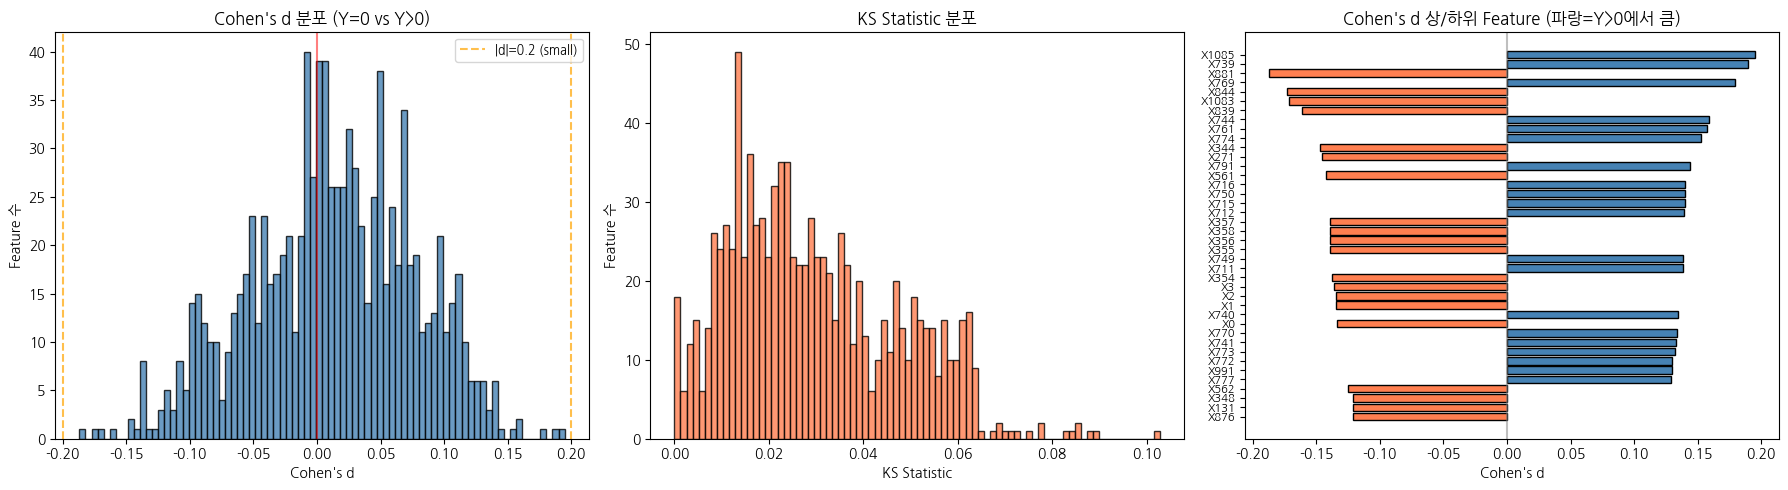

In [28]:
# 통계 검정: Mann-Whitney U + Cohen's d + KS test
test_df = gc.statistical_tests(grp_zero, grp_pos, feat_cols)
gc.plot_test_summary(test_df)

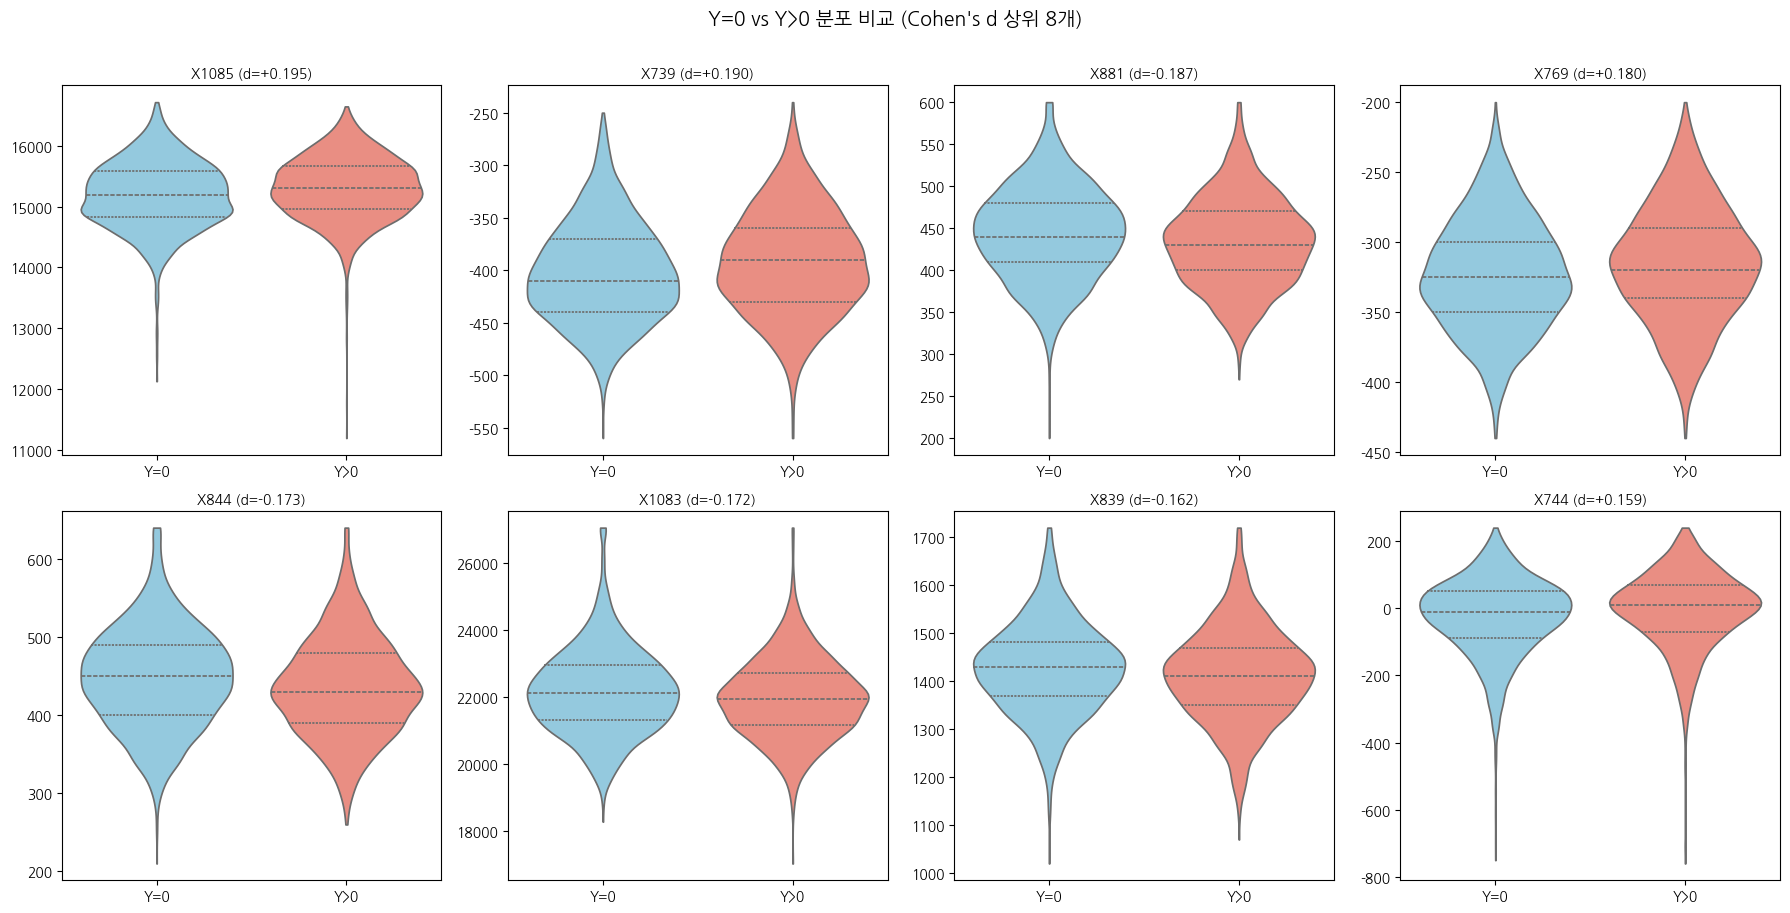

In [29]:
# 상위 feature의 Y=0 vs Y>0 분포 비교 히스토그램
gc.plot_group_distributions(grp_zero, grp_pos, test_df)

Y>0 내부 비교: 하위 10% vs 상위 90%
Y>0 전체: 7,646 units
하위 그룹 (health <= 0.001997): 765 units
상위 그룹 (health >= 0.017554): 765 units

Cohen's d 상위 15개 Feature (Y>0 내 상위 vs 하위):
   Feature    Cohen d    MW p-val
----------------------------------------
       X41    -0.1687    1.86e-03
      X982    -0.1418    1.72e-02
      X774    -0.1418    8.17e-03
      X768    -0.1418    6.53e-03
      X983    -0.1378    2.14e-02
      X120    -0.1368    5.74e-03
      X984    -0.1368    1.76e-02
      X770    -0.1361    1.97e-02
      X773    -0.1309    3.29e-02
      X194    -0.1273    2.79e-02
      X979    -0.1273    3.43e-02
      X772    -0.1270    3.12e-02
      X469    +0.1257    1.42e-02
      X193    -0.1256    3.10e-02
      X204    -0.1253    1.28e-02


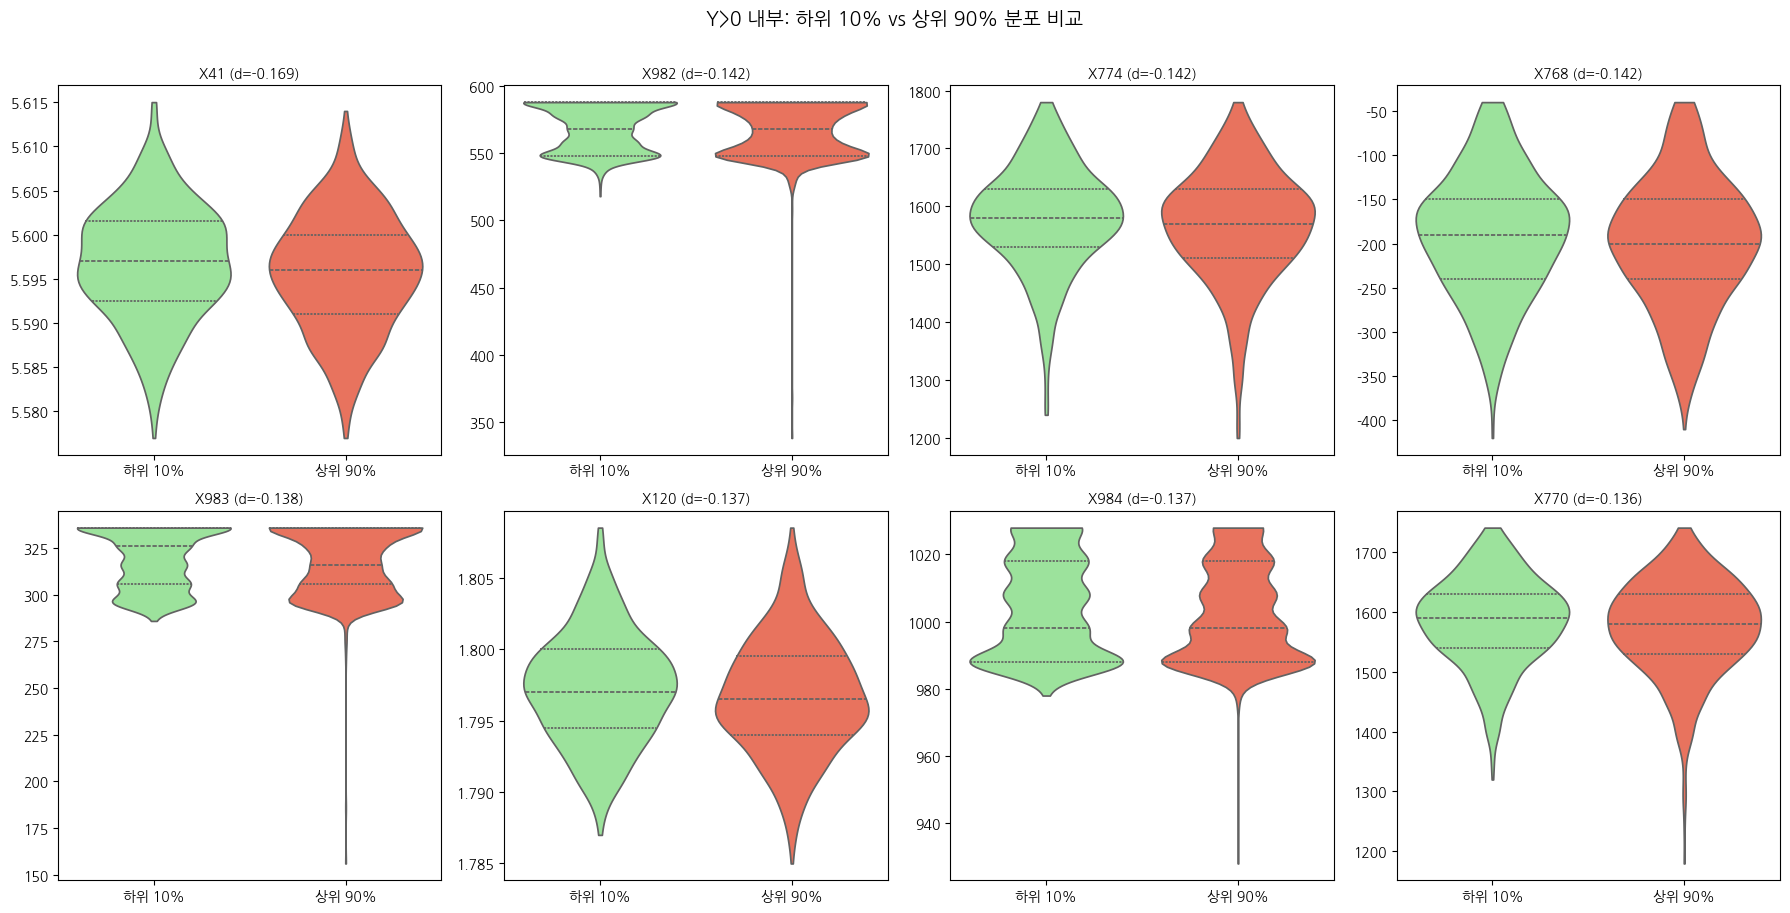

,feature,mw_pvalue,cohens_d
0,X41,0.001864,-0.168747
1,X982,0.017225,-0.141820
2,X774,0.008167,-0.141789
3,X768,0.006529,-0.141783
4,X983,0.021374,-0.137794
...,...,...,...
972,X374,1.000000,0.000000
973,X384,1.000000,0.000000
974,X476,1.000000,0.000000
975,X620,1.000000,0.000000


In [30]:
# Y>0 내부에서도 Low vs High 비교
gc.compare_within_positive(xs_dict, ys_train, feat_cols, test_df)

> **결론 — 15. Y=0 vs Y>0 그룹 비교**
>
> Mann-Whitney 유의(p<0.05): 685개(70.1%), KS 유의: 664개(68.0%). Cohen's d 최대 0.195 — 통계적으로는 유의하지만 효과 크기는 small 미만.
>
> **⭐ Y>0 내부 상위-하위 비교 top feature(X41, X982, X774)가 전체 기준 Pearson top과 다른 집합.** Y=0/Y>0 구분에 유효한 피처와 Y>0 내부 health 크기를 구분하는 피처가 서로 다르다 — Stage 1(분류)와 Stage 2(회귀)용 Feature Selection을 별도로 수행해야 한다.

## 15-1. Zero 발생 메커니즘 검증 (추가)
- Y=0인 unit의 4개 die 중 몇 개가 이상한지 분석
- "1개 die라도 이상하면 Y>0" vs "모든 die 이상해야 Y>0" 패턴 확인
- Two-Stage 분류기 설계의 핵심 근거

이상 die 수별 불량률 (Y>0 비율):
                    불량률  unit 수
n_outlier_die                  
0              0.295971   23134
1              0.276692    2201
2              0.282776     389
3              0.239130     138
4              0.144615     325


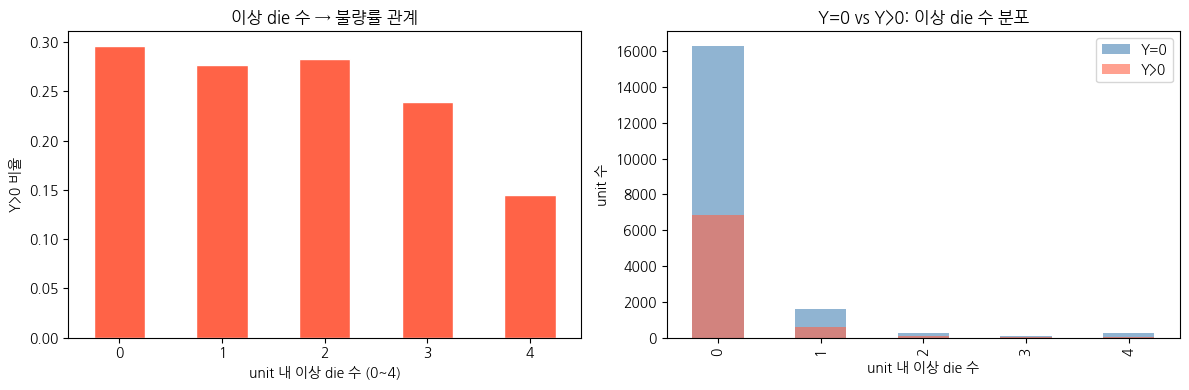

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.config import KEY_COL, TARGET_COL, SPLIT_COL

# train 기준
train_xs = xs[xs[SPLIT_COL] == "train"].copy()
y_ser = ys_train.set_index(KEY_COL)[TARGET_COL]

# 상관 상위 feature 선택 (대표 feature 10개)
train_unit = train_xs.groupby(KEY_COL)[feat_cols].mean()
merged = train_unit.join(y_ser)
top_feats = merged.corr()[TARGET_COL].drop(TARGET_COL).abs().nlargest(10).index.tolist()

# die별로 이상치 여부 판단 (train 기준 Q75+1.5*IQR 초과 = 이상)
ref = train_xs[top_feats]
q75 = ref.quantile(0.75)
q25 = ref.quantile(0.25)
iqr = q75 - q25
upper = q75 + 1.5 * iqr
is_outlier = (train_xs[top_feats] > upper).any(axis=1).astype(int)
train_xs["any_outlier_die"] = is_outlier

# unit별 이상 die 수
outlier_per_unit = train_xs.groupby(KEY_COL)["any_outlier_die"].sum()
unit_df = outlier_per_unit.rename("n_outlier_die").to_frame()
unit_df = unit_df.join(y_ser)
unit_df["is_defect"] = (unit_df[TARGET_COL] > 0).astype(int)

# 이상 die 수별 불량률
defect_rate = unit_df.groupby("n_outlier_die")["is_defect"].mean()
count_per_group = unit_df.groupby("n_outlier_die")["is_defect"].count()
print("이상 die 수별 불량률 (Y>0 비율):")
summary = pd.DataFrame({"불량률": defect_rate, "unit 수": count_per_group})
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
defect_rate.plot(kind="bar", ax=axes[0], color="tomato", edgecolor="white")
axes[0].set_xlabel("unit 내 이상 die 수 (0~4)")
axes[0].set_ylabel("Y>0 비율")
axes[0].set_title("이상 die 수 → 불량률 관계")
axes[0].tick_params(axis="x", rotation=0)

# Y=0 vs Y>0 unit의 이상 die 수 분포
unit_df[unit_df["is_defect"]==0]["n_outlier_die"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], alpha=0.6, label="Y=0", color="steelblue")
unit_df[unit_df["is_defect"]==1]["n_outlier_die"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], alpha=0.6, label="Y>0", color="tomato")
axes[1].set_xlabel("unit 내 이상 die 수")
axes[1].set_ylabel("unit 수")
axes[1].set_title("Y=0 vs Y>0: 이상 die 수 분포")
axes[1].legend()
plt.tight_layout()
plt.show()

> **결론 — E. Zero 발생 메커니즘 검증**
>
> 이상 die 수별 불량률: 0개→29.6%, 1개→27.7%, 2개→28.3%, 3개→23.9%, 4개→14.5%.
>
> **⭐ 이상 die가 많을수록 불량률이 오히려 감소했다 — 예상과 반대 방향.** 대부분의 불량 unit(Y>0)은 이상 die가 0개인 그룹에서 나온다(7,646개 중 대다수). IQR 기준 die 이상치 수가 field health와 직접 연결되지 않음. "이상 die 수"를 Two-Stage 분류기 feature로 쓰는 전략은 근거가 없다.

---
# Phase 7: 집계 전략
모듈: `eda_agg_compare` (agg)

## 26-1. Die 내 이질성 심화 분석 (추가)
- unit 내 4개 die 간 편차(CV)가 target과 연결되는 feature 파악
- 원본 EDA의 CV max|r|=0.147이 실제 신호인지 artifact인지 검증
- 어떤 feature에서 die 간 편차가 클수록 Y>0인지 확인

CV가 mean보다 상관 높은 feature: 236개 / 971개
CV max|r|: 0.0313 (X1079)
mean max|r|: 0.0374 (X1083)


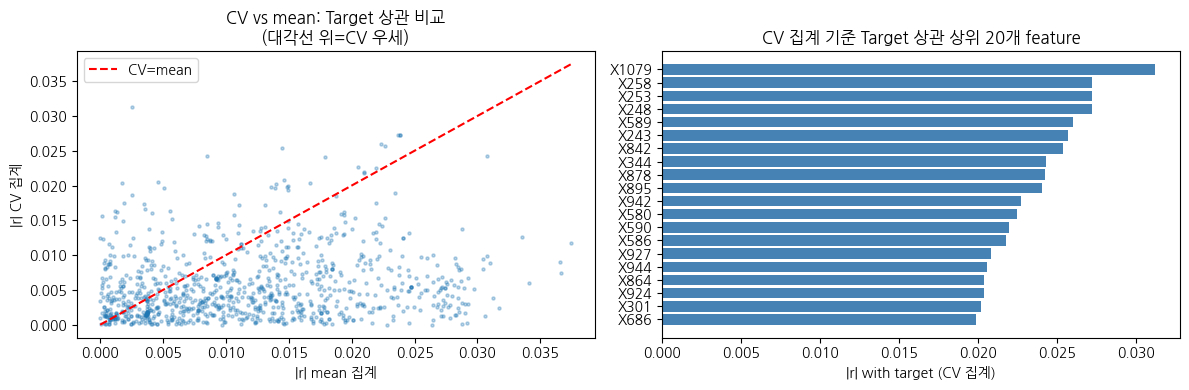

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.config import KEY_COL, TARGET_COL, SPLIT_COL

train_xs = xs[xs[SPLIT_COL] == "train"].copy()
y_ser = ys_train.set_index(KEY_COL)[TARGET_COL]

# unit별 CV 집계
grp = train_xs.groupby(KEY_COL)[feat_cols]
cv_unit = grp.std() / grp.mean().abs().clip(lower=1e-8)

# CV vs target 상관
cv_merged = cv_unit.join(y_ser)
corr_cv = cv_merged.corr()[TARGET_COL].drop(TARGET_COL).abs()

# mean vs target 상관
mean_unit = grp.mean()
mean_merged = mean_unit.join(y_ser)
corr_mean = mean_merged.corr()[TARGET_COL].drop(TARGET_COL).abs()

compare = pd.DataFrame({"CV": corr_cv, "mean": corr_mean}).dropna()
compare["cv_wins"] = compare["CV"] > compare["mean"]
print(f"CV가 mean보다 상관 높은 feature: {compare["cv_wins"].sum()}개 / {len(compare)}개")
print(f"CV max|r|: {corr_cv.max():.4f} ({corr_cv.idxmax()})")
print(f"mean max|r|: {corr_mean.max():.4f} ({corr_mean.idxmax()})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# CV vs mean 상관 scatter
mx = compare[["CV","mean"]].max().max()
axes[0].scatter(compare["mean"], compare["CV"], alpha=0.3, s=5)
axes[0].plot([0, mx], [0, mx], "r--", label="CV=mean")
axes[0].set_xlabel("|r| mean 집계")
axes[0].set_ylabel("|r| CV 집계")
axes[0].set_title("CV vs mean: Target 상관 비교\n(대각선 위=CV 우세)")
axes[0].legend()

# CV 상위 20개 feature
top_cv = corr_cv.nlargest(20)
axes[1].barh(top_cv.index[::-1], top_cv.values[::-1], color="steelblue")
axes[1].set_xlabel("|r| with target (CV 집계)")
axes[1].set_title("CV 집계 기준 Target 상관 상위 20개 feature")
plt.tight_layout()
plt.show()

> **결론 — F. Die 내 이질성 심화 분석**
>
> CV가 mean보다 상관 높은 feature: 236개(24.3%). CV max|r|=0.031 (X1079) — mean max|r|=0.037보다 낮다.
>
> **⭐ 원본 EDA의 CV max|r|=0.147은 X375 단 1개 피처가 만든 수치였으며, X375는 전처리 후 상수가 됐다(제거된 게 아니라 분산이 0).** 전처리 후 실제 CV 신호는 mean과 동급. "CV가 die 집계의 핵심"이라는 원본 해석은 폐기. 9종 집계 균등 생성 후 Feature Selection으로 선별하는 방향이 맞다.

## 26. 집계 방식별 Target 상관 비교

In [33]:
# 11가지 집계 함수별 target 상관계수 계산 (기존 7종 + Q25, Q75, kurtosis, CV)
corr_by_agg, summary_df = agg.compute_agg_correlations(xs_dict, ys_train, feat_cols)
agg.print_agg_summary(corr_by_agg, summary_df)

집계 방식별 Target 상관계수 요약
        집계    max|r|    mean|r|   |r|>0.03   |r|>0.05    top1 feature
----------------------------------------------------------------------
      mean    0.0374     0.0116         13          0           X1083
       std    0.0314     0.0057          1          0           X1079
       min    0.0372     0.0096          5          0           X1083
       max    0.0362     0.0113         24          0            X761
     range    0.0297     0.0057          0          0           X1079
    median    0.0376     0.0116          9          0           X1085
      skew    0.0204     0.0051          0          0            X687
       Q25    0.0391     0.0107          6          0           X1083
       Q75    0.0385     0.0116         12          0           X1085
  kurtosis    0.0263     0.0050          0          0            X942
        CV    0.0359     0.0061         10          0            X368

Feature별 최적 집계 방식 분포 (|r| 최대인 집계):
       max: 173개 (17.7%)
      

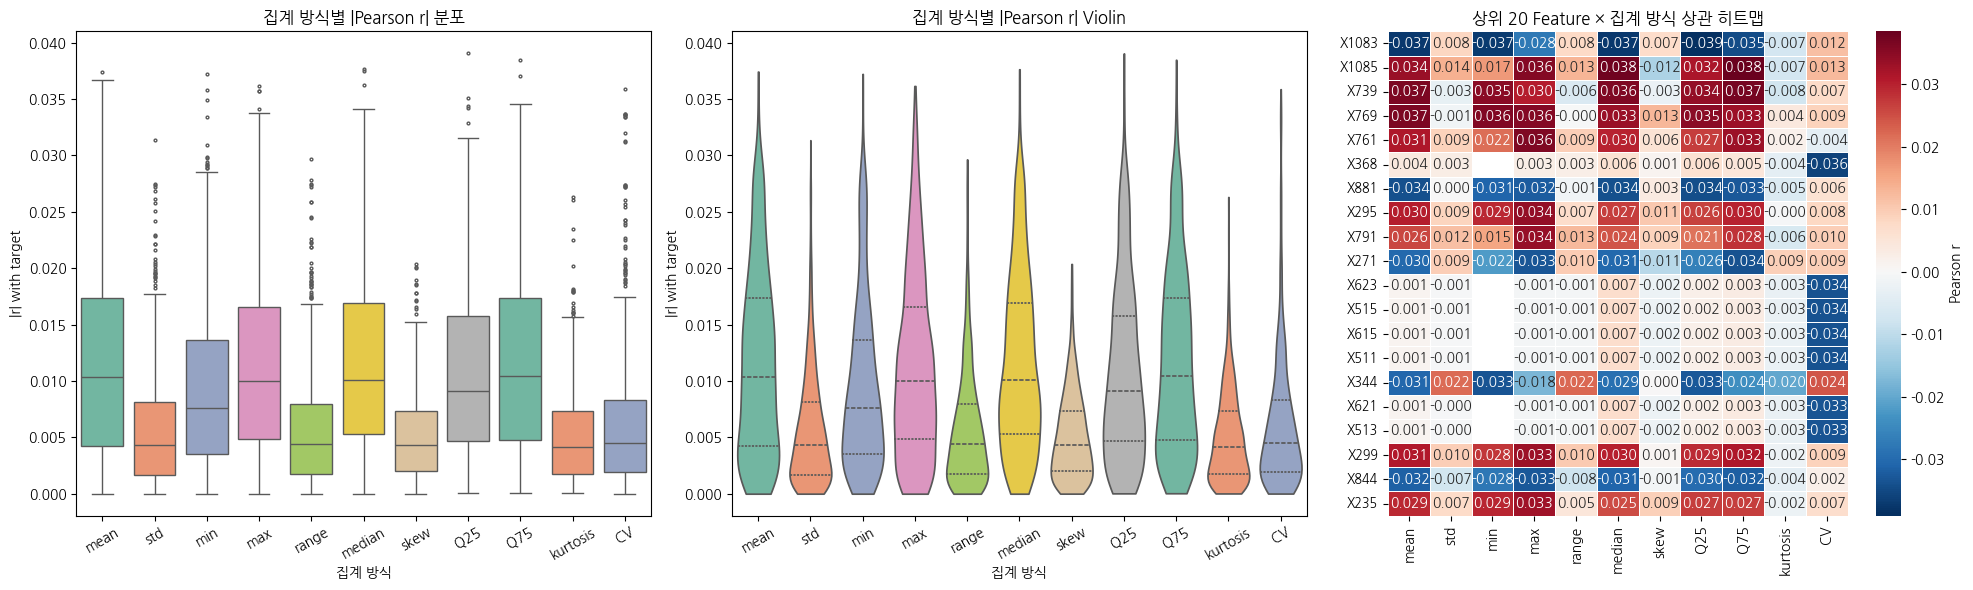

In [34]:
# 집계 방식별 상관 비교 시각화
agg.plot_agg_comparison(corr_by_agg, summary_df)

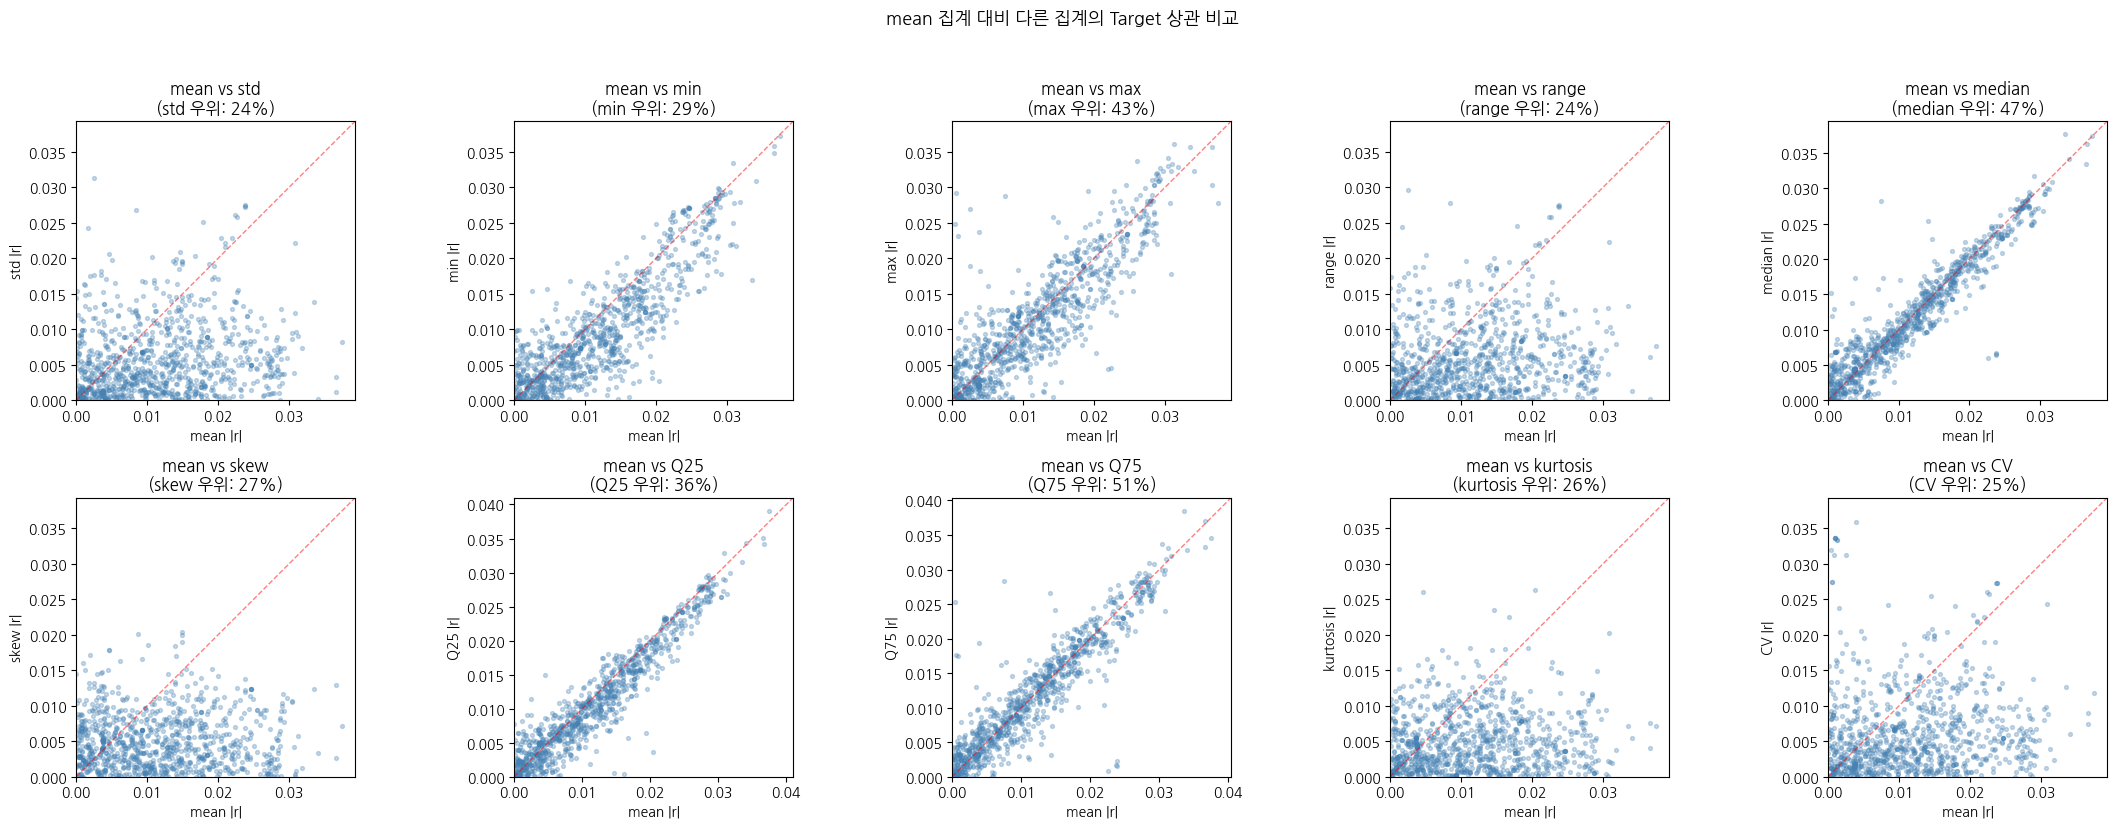

mean 외 집계가 더 좋은 상위 15개 Feature
   Feature      최적집계   best|r|   mean|r|        향상
-------------------------------------------------------
      X623        CV    0.0337    0.0010   +0.0327
      X515        CV    0.0337    0.0010   +0.0327
      X511        CV    0.0336    0.0010   +0.0326
      X615        CV    0.0336    0.0010   +0.0326
      X621        CV    0.0334    0.0012   +0.0322
      X513        CV    0.0334    0.0012   +0.0322
      X368        CV    0.0359    0.0039   +0.0319
      X516        CV    0.0320    0.0005   +0.0315
      X636        CV    0.0312    0.0009   +0.0303
     X1079       std    0.0314    0.0025   +0.0288
      X255       max    0.0292    0.0005   +0.0287
      X622        CV    0.0274    0.0005   +0.0268
      X514        CV    0.0274    0.0005   +0.0268
      X245       Q75    0.0253    0.0004   +0.0249
      X864     range    0.0245    0.0017   +0.0228


,feature,best_agg,best_r,mean_r,gain_over_mean
0,X623,CV,0.033692,0.000980,0.032712
1,X515,CV,0.033692,0.000980,0.032712
2,X511,CV,0.033618,0.001000,0.032618
3,X615,CV,0.033618,0.001000,0.032618
4,X621,CV,0.033384,0.001188,0.032197
...,...,...,...,...,...
972,X375,NaN,NaN,NaN,NaN
973,X384,NaN,NaN,NaN,NaN
974,X512,NaN,NaN,NaN,NaN
975,X620,NaN,NaN,NaN,NaN


In [35]:
# mean 대비 다른 집계 방식의 우위 feature + 최적 집계 조합 추천
agg.plot_mean_vs_others(summary_df)
agg.find_best_agg_features(summary_df)

> **결론 — 26. 집계 방식별 Target 상관 비교**
>
> 집계 방식별 max|r|: mean 0.037, median 0.038, Q25 0.039, Q75 0.039, max 0.036, std 0.031, CV 0.036. 방식 간 차이가 미미하다. 단, 최적 집계가 max인 feature 173개(17.7%), Q75 137개(14.0%) — 극단 die 값이 평균보다 target과 더 잘 연결되는 feature가 존재한다.

## 26-2. 전처리 후 집계별 Feature-Target 상관 (추가)
- 전처리된 die-level -> unit 집계 후 상관
- mean/std/CV 등 집계 방식별 상관 비교
- 원본 EDA Phase 26 결과와 비교 -> 전처리 효과 확인

                  mean     std     min     max  median      CV
max|r|          0.0374  0.0314  0.0372  0.0362  0.0376  0.0313
mean|r|         0.0116  0.0057  0.0096  0.0113  0.0116  0.0056
|r|>0.05 count  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000


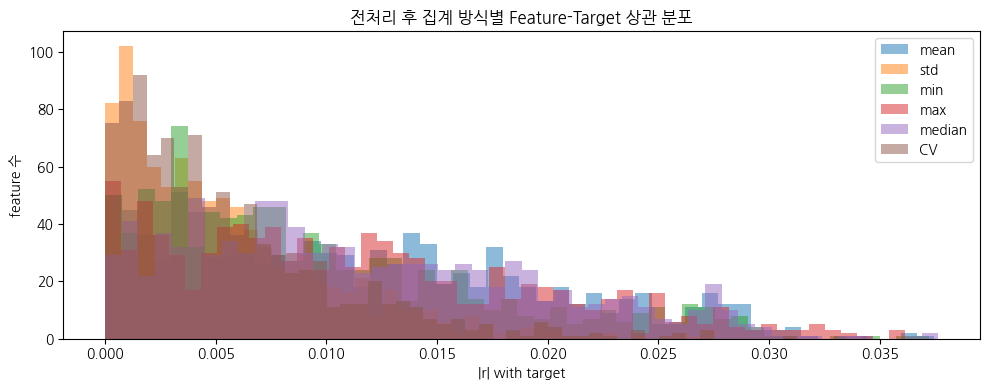

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.config import KEY_COL, TARGET_COL, SPLIT_COL

train_xs = xs[xs[SPLIT_COL] == "train"].copy()
y_ser = ys_train.set_index(KEY_COL)[TARGET_COL]

agg_funcs = {
    "mean":   lambda g: g.mean(),
    "std":    lambda g: g.std(),
    "min":    lambda g: g.min(),
    "max":    lambda g: g.max(),
    "median": lambda g: g.median(),
    "CV":     lambda g: g.std() / g.mean().abs().clip(lower=1e-8),
}

results = {}
for name, fn in agg_funcs.items():
    agg = fn(train_xs.groupby(KEY_COL)[feat_cols])
    merged = agg.join(y_ser)
    corr = merged.corr()[TARGET_COL].drop(TARGET_COL).abs()
    results[name] = corr

summary = pd.DataFrame({k: [v.max(), v.mean(), (v > 0.05).sum()]
                         for k, v in results.items()},
                        index=["max|r|", "mean|r|", "|r|>0.05 count"])
print(summary.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
for name, corr in results.items():
    ax.hist(corr, bins=50, alpha=0.5, label=name)
ax.set_xlabel("|r| with target")
ax.set_ylabel("feature 수")
ax.set_title("전처리 후 집계 방식별 Feature-Target 상관 분포")
ax.legend()
plt.tight_layout()
plt.show()

> **결론 — C. 전처리 후 집계별 Feature-Target 상관**
>
> 전처리 전후 집계별 max|r| 비교: mean/median/Q25/Q75는 거의 동일. CV만 0.147→0.031로 급락 — 원본 CV 신호를 이끌던 X375·X384가 전처리 후 상수 feature가 됐기 때문. 전처리 후 집계 방식 간 차이가 매우 작으므로 9종 전체 생성 후 Feature Selection에서 자연선별하는 전략이 합리적.